# T2D Microbiome Project
## Research Question
Can gut microbiome profiles distinguish **T2D** from **non-T2D**, and which taxonomic representation is most reliable for prediction?


## Abstract
In this notebook we test whether gut microbiome profiles can separate **T2D** from **non-T2D** in our cohort.
We follow a full course-aligned pipeline: leakage-safe preprocessing, TAXA-level comparison, classical ML models, a taxonomy-aware CNN baseline, unsupervised visualization, statistical testing, multiple-testing correction, and explainability.


## Introduction
Our project question is practical: can microbiome composition help classify T2D, and at which taxonomic representation does performance look most reliable?

Because this dataset is sparse and high-dimensional, we keep the hierarchy explicit (species/genus/subPCA), compare multiple models, and then check both predictive quality and biological interpretability.


In [7]:
import matplotlib
matplotlib.use('Agg')  # חובה! מנתק את היכולת לפתוח חלונות קופצים

# Standard Library
import os
import re
import shutil
from pathlib import Path
from IPython.display import display, Image

# Data Manipulation & Math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Statistics & Hypothesis Testing
from scipy.stats import entropy, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Machine Learning (Scikit-Learn)
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Project-Specific & Bioinformatics Libraries
from MIPMLP import preprocess, micro2matrix, CNN
from mimic_da import apply_mimic
from mimic_da.miMic_test import apply_nested_anova

In [8]:
def save_and_show(filename):
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    display(Image(filename=filename))

In [9]:
df = pd.read_csv('T2D_microbiome_dataset_2.csv')

microbiome_cols = [col for col in df.columns if col.startswith('species:') or col.startswith('genus:')]

X = df[microbiome_cols].copy()
y = df['label'].copy()

print(f"Initial dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")

Initial dataset shape: (116, 498)
Class distribution:
label
T2D        63
healthy    53
Name: count, dtype: int64


In [10]:
# ==========================================
# 1.3 Preprocessing using official MIPMLP Pipeline
# ==========================================
X_mip = X.copy()

# התאמת המבנה לדרישות של MIPMLP
X_mip['ID'] = X_mip.index
X_mip = X_mip.astype(object)

# הוספת שורת הטקסונומיה לפי שמות העמודות
X_mip.loc['taxonomy'] = pd.Series(X_mip.columns, index=X_mip.columns)
X_mip.loc['taxonomy', 'ID'] = 'taxonomy'

# הפעלת העיבוד המקדים
X_processed = preprocess(
    X_mip, 
    taxonomy_level=7,          # רמת Species
    taxnomy_group='sum', 
    normalization='relative', 
    rare_bacteria_threshold=0.05, # סינון רעשים וחיידקים נדירים (סף 5%)
    plot=False
)

print(f"Processed shape (after MIPMLP filtering): {X_processed.shape}")

Processed shape (after MIPMLP filtering): (116, 258)


c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\MIPMLP\preprocess_grid.py:48: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  as_data_frame = pd.DataFrame(data.T).apply(pd.to_numeric, errors='ignore').copy()  # data frame of OTUs
c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\MIPMLP\preprocess_grid.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if str(as_data_frame[taxonomy_col][i])[0].lower() > min_letter_value and as_data_frame[taxonomy_col][i].split(';')[0][-len("Viruses"):] != "Viruses":
c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\MIPMLP\preprocess_grid.py:57: FutureWarning: Series.__getitem__ treati

In [11]:
# ==========================================
# 1.4 Global Log Transformation
# ==========================================
# מבוצע פעם אחת כאן כדי לשמש אותנו בהמשך למודלים הטבלאיים ולויזואליזציות
print("Applying Global Log Transformation...")
X_log = np.log10(X_processed + 1e-6)

# הצגת הצצה לנתונים המעובדים
display(X_log.head())

Applying Global Log Transformation...


,genus:Streptococcus,species:Actinomyces graevenitzii,species:Actinomyces naeslundii,species:Actinomyces oris,species:Actinomyces sp. HMSC035G02,species:Actinomyces sp. HPA0247,species:Actinomyces sp. ICM47,species:Actinomyces sp. S6-Spd3,species:Actinomyces sp. oral taxon 181,species:Adlercreutzia caecimuris,...,species:[Clostridium] leptum,species:[Clostridium] methylpentosum,species:[Clostridium] scindens,species:[Clostridium] spiroforme,species:[Clostridium] symbiosum,species:[Eubacterium] rectale,species:[Eubacterium] siraeum,species:[Ruminococcus] gnavus,species:[Ruminococcus] lactaris,species:[Ruminococcus] torques
0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-4.439946,...,-6.000000,-6.0,-6.0,-6.000000,-6.0,-2.232151,-3.213026,-6.000000,-2.524744,-2.616195
1,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-4.318516,...,-3.370139,-6.0,-6.0,-3.005171,-6.0,-4.333239,-2.378815,-6.000000,-2.749943,-2.033371
2,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.000000,...,-3.897939,-6.0,-6.0,-6.000000,-6.0,-1.842057,-1.231404,-4.091592,-1.680358,-2.581320
3,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-4.829106,...,-1.743085,-6.0,-6.0,-6.000000,-6.0,-2.448299,-2.855091,-6.000000,-1.815480,-2.339282
4,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.0,-6.000000,...,-6.000000,-6.0,-6.0,-6.000000,-6.0,-1.874766,-2.295681,-6.000000,-2.965868,-1.701219


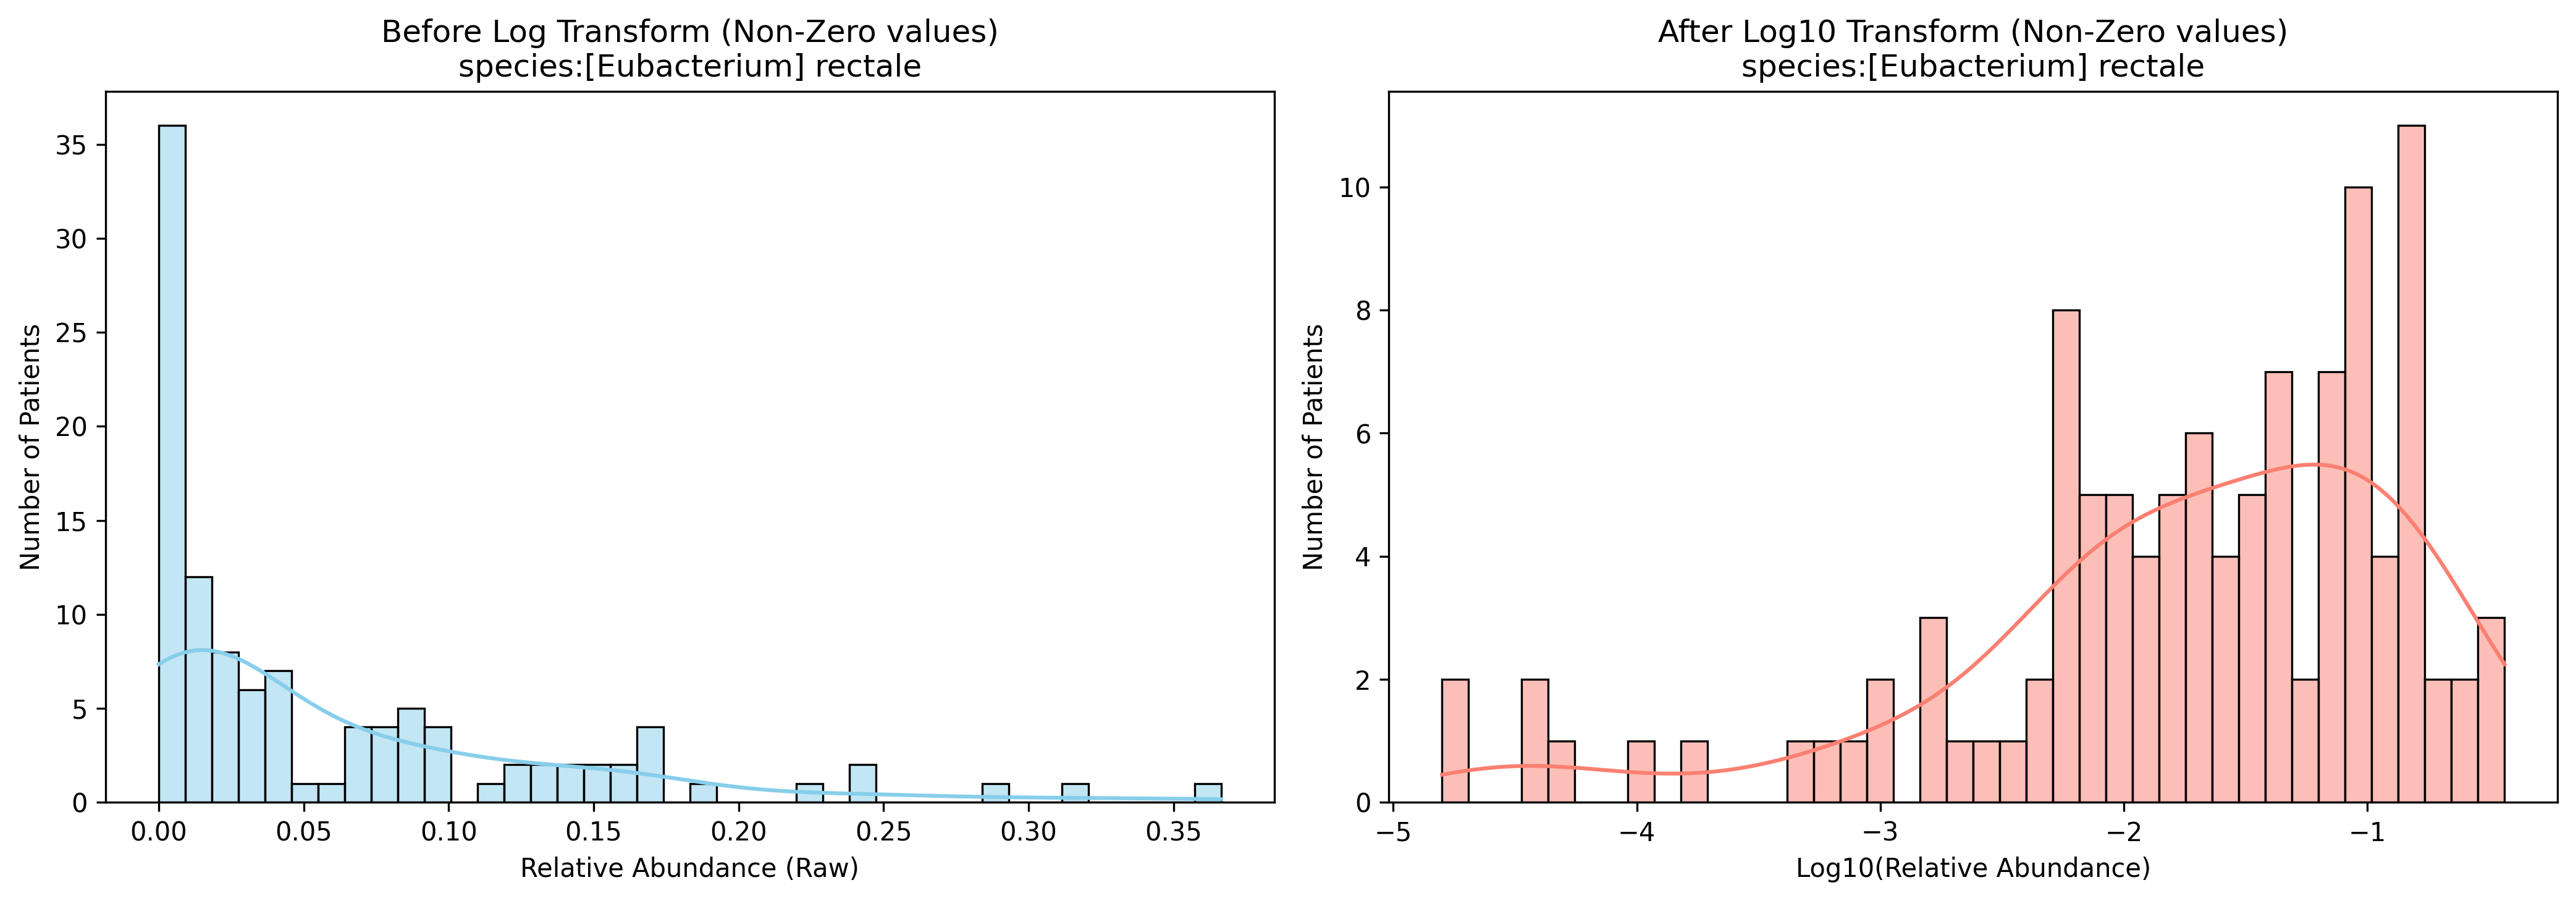

In [12]:
# 1. מציאת החיידק האידיאלי להדגמה (זה עם השונות הגבוהה ביותר)
variances = X_processed.var()
best_bacterium = variances.idxmax()

# חילוץ הנתונים של החיידק הספציפי
data_raw = X_processed[best_bacterium]

# 2. סינון מטופלים עם ערך "0" (רק לטובת הציור, כדי שהאפסים לא ימעכו את הגרף)
data_raw_nonzero = data_raw[data_raw > 0]
# נעשה לוגריתם רק על הערכים החיוביים (כאן אפשר בלי ה-pseudo count כי אין אפסים)
data_log_nonzero = np.log10(data_raw_nonzero)

plt.figure(figsize=(14, 5))

# --- גרף שמאלי: נתונים גולמיים מעוטי אפסים ---
plt.subplot(1, 2, 1)
# הגדלנו את כמות ה-bins ל-40 כדי לקבל רזולוציה טובה יותר
sns.histplot(data_raw_nonzero, bins=40, kde=True, color='skyblue')
plt.title(f'Before Log Transform (Non-Zero values)\n{best_bacterium}', fontsize=12)
plt.xlabel('Relative Abundance (Raw)')
plt.ylabel('Number of Patients')

# --- גרף ימני: אחרי התמרת הלוג ---
plt.subplot(1, 2, 2)
sns.histplot(data_log_nonzero, bins=40, kde=True, color='salmon')
plt.title(f'After Log10 Transform (Non-Zero values)\n{best_bacterium}', fontsize=12)
plt.xlabel('Log10(Relative Abundance)')
plt.ylabel('Number of Patients')

plt.tight_layout()
save_and_show('plots//After Log10 Transform.png')

C:\Users\ofekh\AppData\Local\Temp\ipykernel_38576\3974703318.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_healthy.values, y=top5_healthy.index, palette='Greens_r')
C:\Users\ofekh\AppData\Local\Temp\ipykernel_38576\3974703318.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_t2d.values, y=top5_t2d.index, palette='Reds_r')


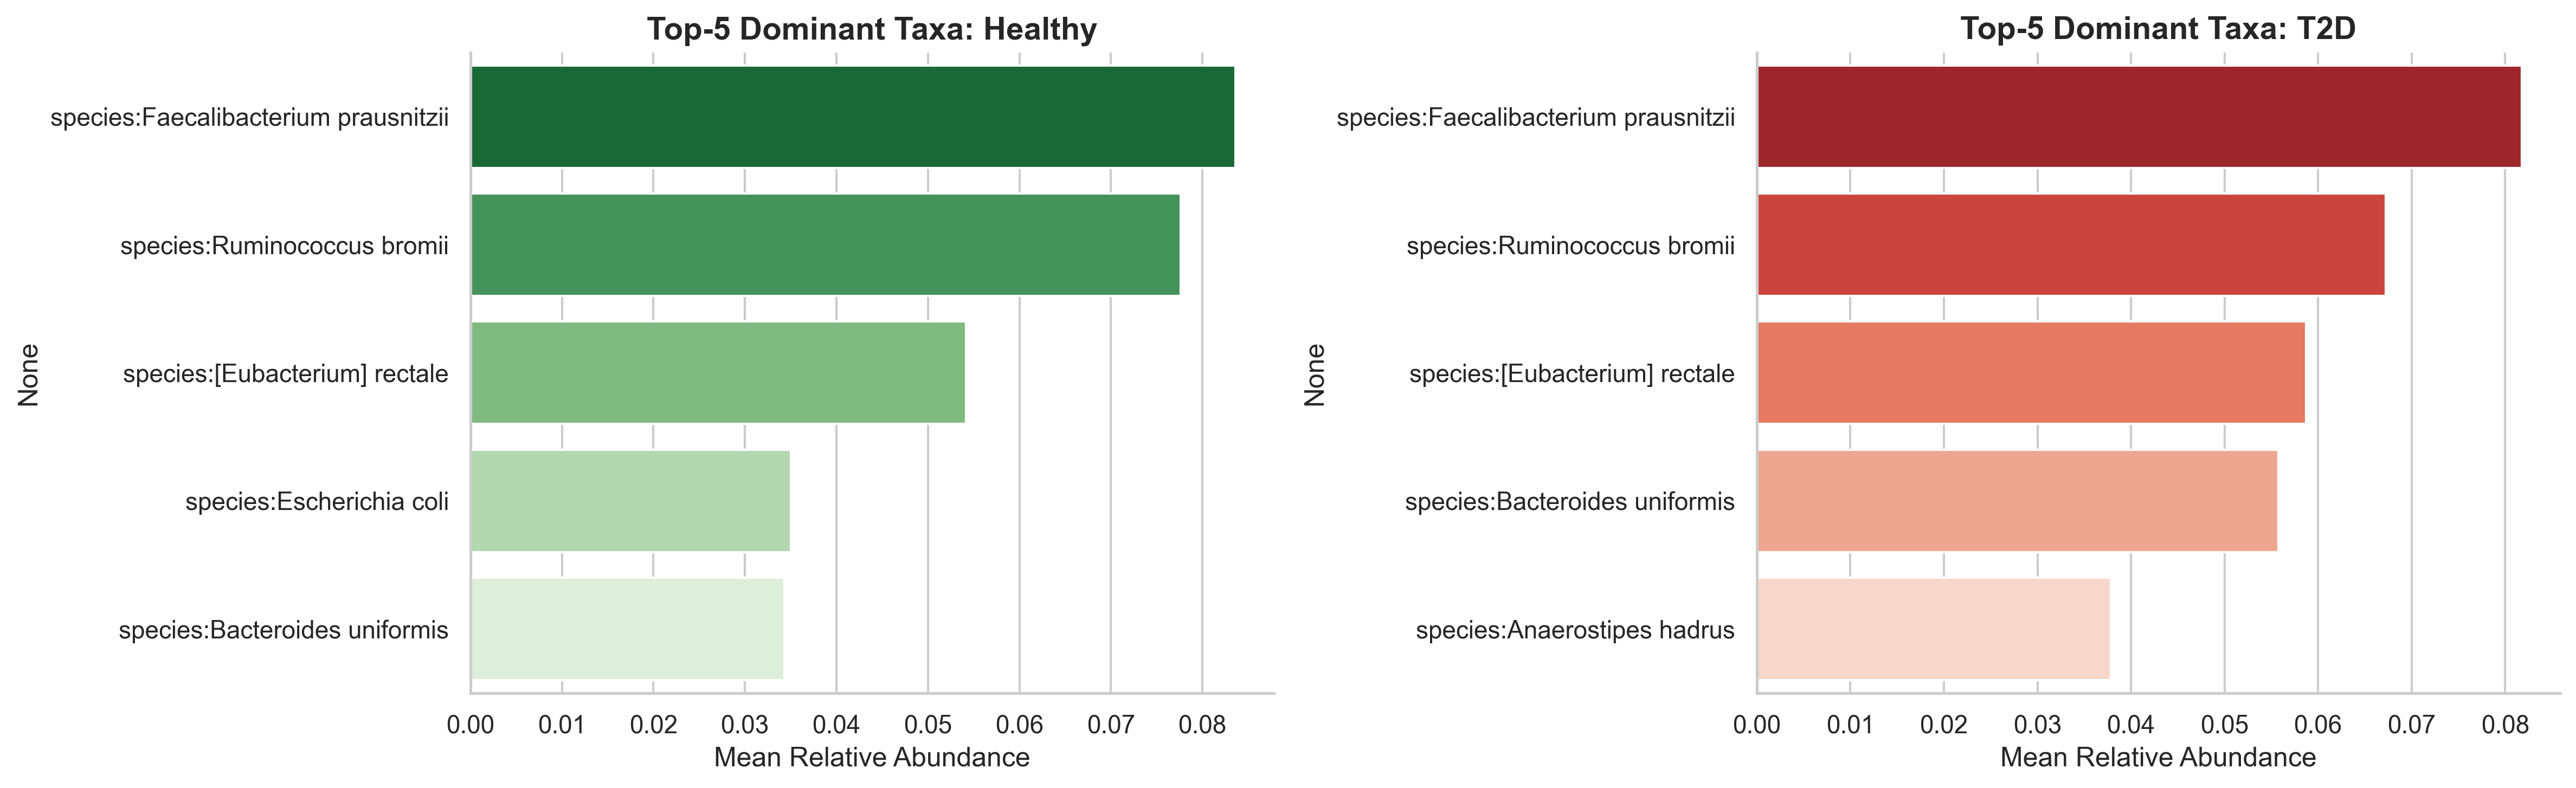

--- Top 5 Taxa in Healthy Cohort ---
species:Faecalibacterium prausnitzii    0.083608
species:Ruminococcus bromii             0.077635
species:[Eubacterium] rectale           0.054152
species:Escherichia coli                0.035009
species:Bacteroides uniformis           0.034340
Name: healthy, dtype: float64

--- Top 5 Taxa in T2D Cohort ---
species:Faecalibacterium prausnitzii    0.081773
species:Ruminococcus bromii             0.067227
species:[Eubacterium] rectale           0.058731
species:Bacteroides uniformis           0.055783
species:Anaerostipes hadrus             0.037832
Name: T2D, dtype: float64


In [13]:
# Ensure data is clean of any string rows (like 'taxonomy') and indices are aligned
X_mean = X_processed.drop(index='taxonomy', errors='ignore').astype(float).copy()
X_mean['Label'] = y.values

# Calculate the mean relative abundance for each feature, grouped by class
mean_abundance = X_mean.groupby('Label').mean().T

# Extract the Top-5 features for the 'healthy' group
top5_healthy = mean_abundance['healthy'].sort_values(ascending=False).head(5)

# Extract the Top-5 features for the 'T2D' group
top5_t2d = mean_abundance['T2D'].sort_values(ascending=False).head(5)

# ---------------------------------------------------------
# Visualization: Side-by-side horizontal bar charts
# ---------------------------------------------------------
plt.figure(figsize=(16, 5))
sns.set_theme(style="whitegrid")

# Plot Healthy Top-5 (Green palette)
plt.subplot(1, 2, 1)
# Note: No 'ax=axes' here. It draws directly on the left subplot.
sns.barplot(x=top5_healthy.values, y=top5_healthy.index, palette='Greens_r')
plt.title('Top-5 Dominant Taxa: Healthy', fontsize=14, fontweight='bold')
plt.xlabel('Mean Relative Abundance', fontsize=12)

# Plot T2D Top-5 (Red palette)
plt.subplot(1, 2, 2)
# Note: No 'ax=axes' here either. It draws directly on the right subplot.
sns.barplot(x=top5_t2d.values, y=top5_t2d.index, palette='Reds_r')
plt.title('Top-5 Dominant Taxa: T2D', fontsize=14, fontweight='bold')
plt.xlabel('Mean Relative Abundance', fontsize=12)

# Clean up layout
sns.despine()
plt.tight_layout()
save_and_show('plots//Top-5 Dominant TaxaT2D.png')

# Print text summaries
print("--- Top 5 Taxa in Healthy Cohort ---")
print(top5_healthy)
print("\n--- Top 5 Taxa in T2D Cohort ---")
print(top5_t2d)

### Exploratory Data Analysis: Top-5 Dominant Taxa per Class

In this section, we aimed to identify the most highly abundant bacterial species within each health state before moving to formal statistical testing. 

**Methodology:**
1. **Aggregation:** We calculated the mean relative abundance of every microbial feature across all patients, grouped by their clinical label (`healthy` vs. `T2D`).
2. **Ranking:** The features were sorted in descending order to extract the absolute top-5 dominant taxa for each cohort.
3. **Visualization:** We generated a side-by-side horizontal bar chart to visually compare these baseline microbial profiles.

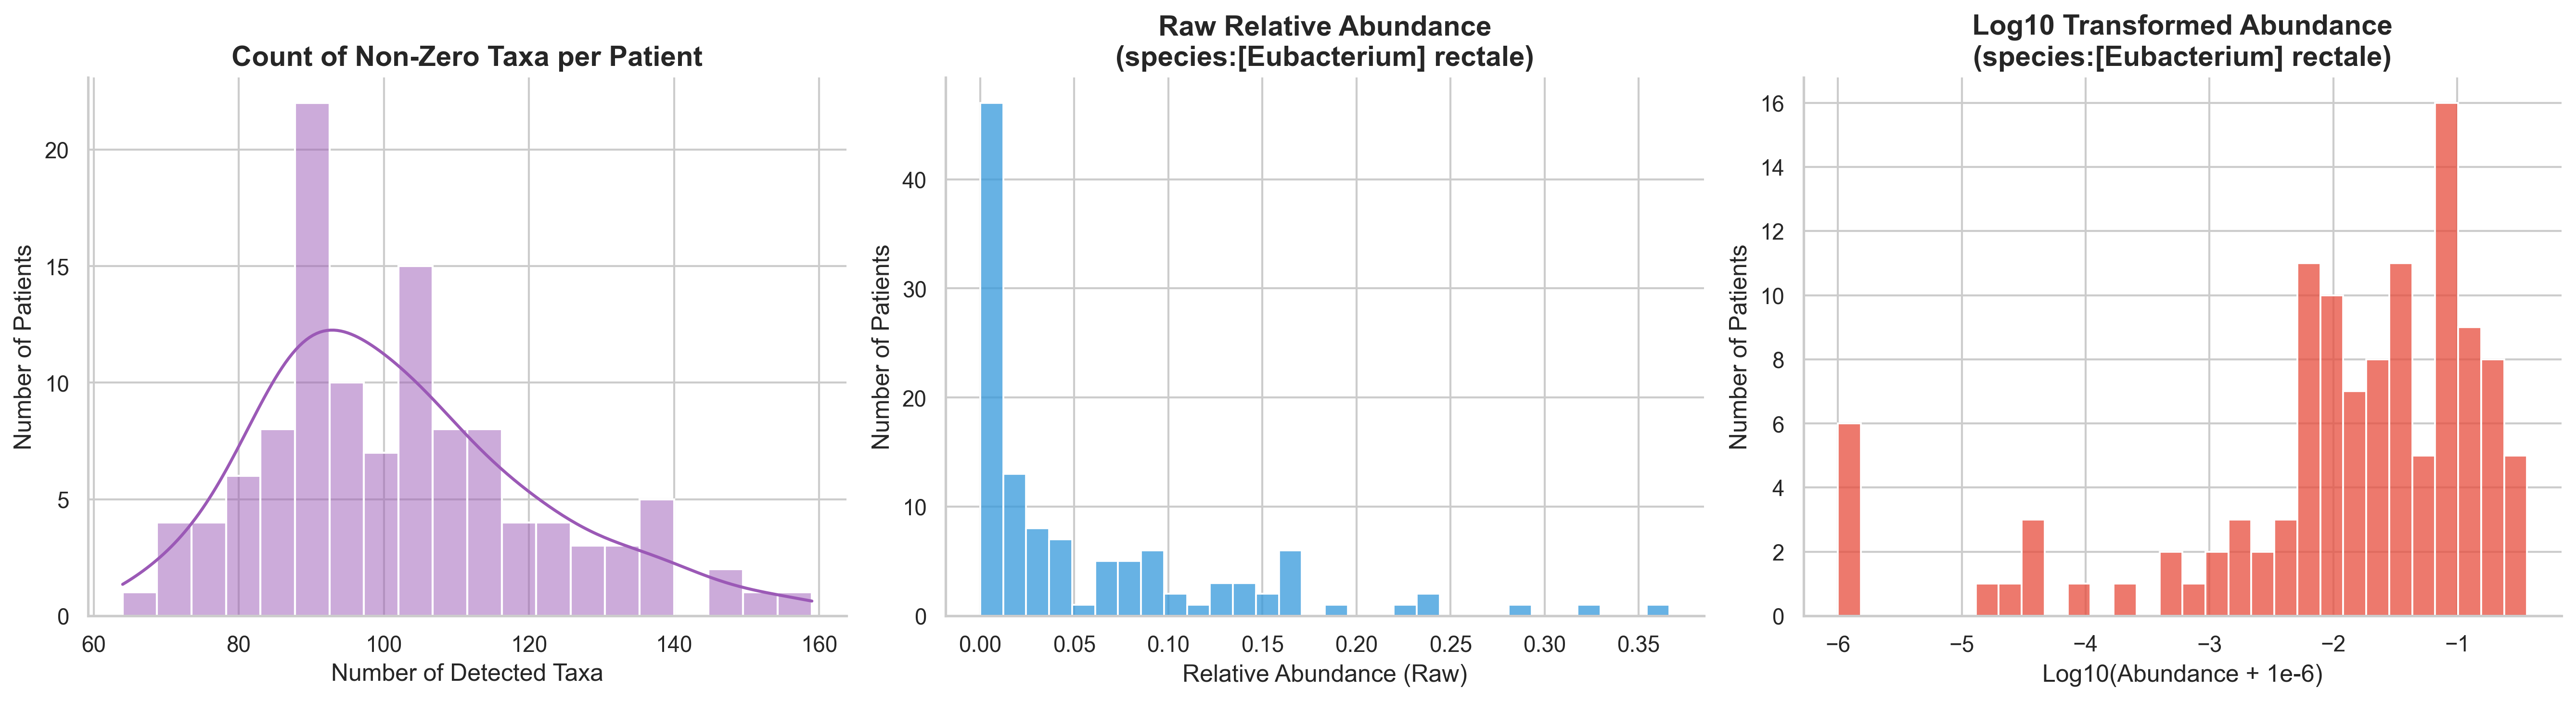

In [14]:
# Ensure data is clean of any string rows and indices are aligned
X_clean = X_processed.drop(index='taxonomy', errors='ignore').astype(float).copy()
X_log_clean = X_log.drop(index='taxonomy', errors='ignore').astype(float).copy()

# 1. Calculate the number of non-zero taxa per patient
non_zero_counts = (X_clean > 0).sum(axis=1)

# 2. Select the most variable bacterium to demonstrate the transformation
best_bacterium = X_clean.var().idxmax()
data_raw = X_clean[best_bacterium]
data_log = X_log_clean[best_bacterium]

# ---------------------------------------------------------
# Visualization: 1x3 Subplots Layout
# ---------------------------------------------------------
plt.figure(figsize=(18, 5))
sns.set_theme(style="whitegrid")

# --- Plot 1: Number of Non-Zero Taxa per Patient ---
plt.subplot(1, 3, 1)
sns.histplot(non_zero_counts, bins=20, kde=True, color='#9b59b6')
plt.title('Count of Non-Zero Taxa per Patient', fontsize=14, fontweight='bold')
plt.xlabel('Number of Detected Taxa', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# --- Plot 2: Raw Relative Abundance ---
plt.subplot(1, 3, 2)
sns.histplot(data_raw, bins=30, kde=False, color='#3498db')
plt.title(f'Raw Relative Abundance\n({best_bacterium})', fontsize=14, fontweight='bold')
plt.xlabel('Relative Abundance (Raw)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# --- Plot 3: Log Transformed Relative Abundance ---
plt.subplot(1, 3, 3)
sns.histplot(data_log, bins=30, kde=False, color='#e74c3c')
plt.title(f'Log10 Transformed Abundance\n({best_bacterium})', fontsize=14, fontweight='bold')
plt.xlabel('Log10(Abundance + 1e-6)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Clean up layout
sns.despine()
plt.tight_layout()
save_and_show('plots//Log10 Transformed Abundance.png')

### Exploratory Data Analysis: Sparsity and Log Transformation Effects

In this section, we visualized the inherent sparsity of the microbiome dataset alongside the mathematical impact of the preprocessing pipeline.

**Methodology & Visualizations:**
1. **Count of Non-Zero Taxa per Patient (Left):** We calculated the total number of bacterial features with a value greater than zero for each patient. This illustrates the richness of the samples and highlights the overall sparsity of the dataset, as a significant portion of the total taxa remains undetected in any given patient.
2. **Raw Relative Abundance (Center):** We selected the most highly variable bacterial species to demonstrate its raw data distribution. The severe right-skew and the massive peak at zero (Zero-Inflation) demonstrate the mathematical challenges of raw compositional data.
3. **Log10 Transformed Abundance (Right):** We plotted the exact same bacterium after applying the global $\log_{10}(X + 10^{-6})$ transformation. The extreme skew is mitigated, compressing the extreme high values and spreading the zero/low values. This results in a more symmetrical distribution that is statistically stable for evaluation.

Found 16 significant taxa (FDR < 0.05)



,taxon,p_value,fdr_q_value,log2fc
130,species:Firmicutes bacterium CAG:555,0.002564,0.042065,-5.725103
16,species:Alistipes indistinctus,0.000710,0.018616,-1.816106
205,species:Roseburia sp. CAG:182,0.000002,0.000223,-1.544247
20,species:Alistipes shahii,0.000002,0.000223,-1.517280
15,species:Alistipes finegoldii,0.000237,0.007638,-1.457390
33,species:Bacteroides cellulosilyticus,0.001070,0.022825,-1.343750
17,species:Alistipes inops,0.000722,0.018616,-1.006801
256,species:[Ruminococcus] lactaris,0.001150,0.022825,-0.606332
133,species:Firmicutes bacterium CAG:95,0.002609,0.042065,-0.449055
109,species:Enterocloster lavalensis,0.000217,0.007638,2.276181


C:\Users\ofekh\AppData\Local\Temp\ipykernel_38576\1432772732.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


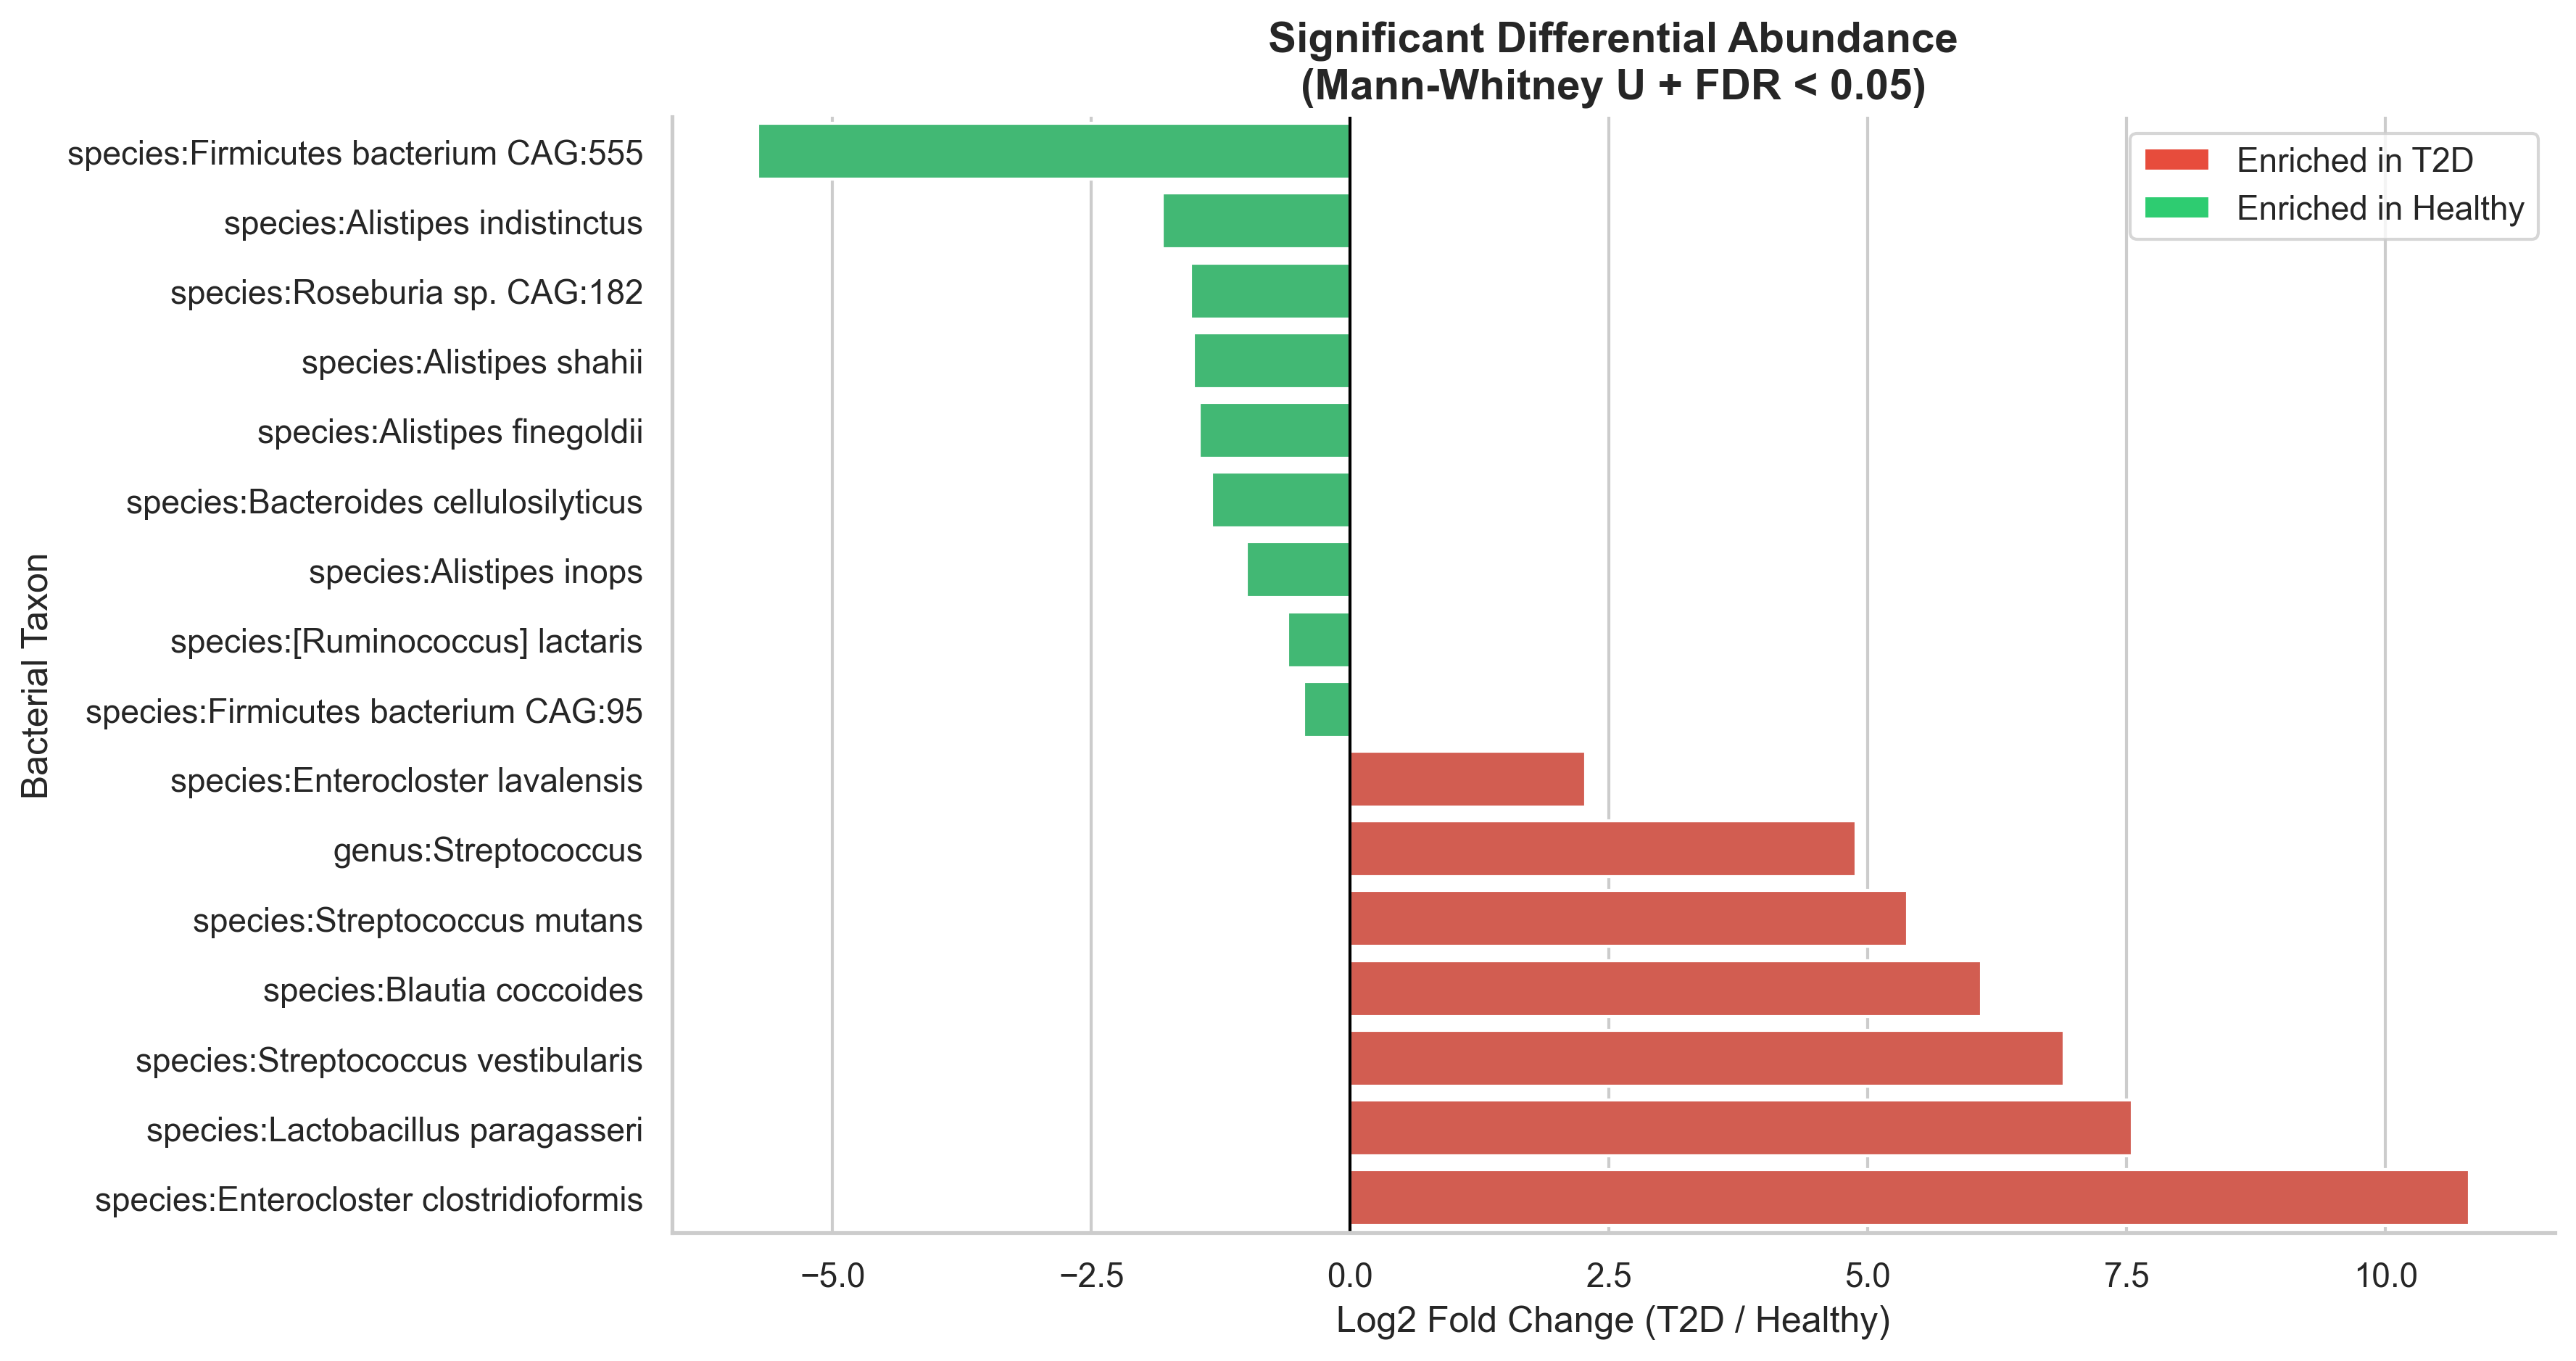

In [15]:
# Ensure data is numeric and free of the taxonomy string row
X_stat = X_processed.drop(index='taxonomy', errors='ignore').astype(float).copy()
y_stat = y.copy()

# Ensure exact index alignment
X_stat.index = y_stat.index

results = []

# Iterate over all bacterial features
for taxon in X_stat.columns:
    # Split the data into our two target classes
    group_healthy = X_stat.loc[y_stat == 'healthy', taxon]
    group_t2d = X_stat.loc[y_stat == 'T2D', taxon]
    
    # 1. Mann-Whitney U Test (Non-parametric)
    stat, p_val = mannwhitneyu(group_healthy, group_t2d, alternative='two-sided')
    
    # 2. Log2 Fold Change Calculation
    # We add a small pseudo-count (1e-6) to prevent division by zero
    mean_healthy = group_healthy.mean() + 1e-6
    mean_t2d = group_t2d.mean() + 1e-6
    l2fc = np.log2(mean_t2d / mean_healthy)
    
    results.append({
        'taxon': taxon,
        'p_value': p_val,
        'log2fc': l2fc
    })

# Convert to DataFrame
df_stats = pd.DataFrame(results)

# 3. Apply FDR Correction (Benjamini-Hochberg) to account for multiple testing
_, df_stats['fdr_q_value'], _, _ = multipletests(df_stats['p_value'], method='fdr_bh')

# Filter for statistically significant taxa (FDR < 0.05)
sig_threshold = 0.05
sig_taxa = df_stats[df_stats['fdr_q_value'] < sig_threshold].sort_values('log2fc').copy()

print(f"Found {len(sig_taxa)} significant taxa (FDR < {sig_threshold})\n")
display(sig_taxa[['taxon', 'p_value', 'fdr_q_value', 'log2fc']].head(15))

# ==========================================
# Visualization: Diverging Bar Plot (Alternative to Volcano Plot)
# ==========================================
# If there are too many significant taxa, plot only the top 20 most significant ones for readability
if len(sig_taxa) > 20:
    plot_data = sig_taxa.sort_values('fdr_q_value').head(20).sort_values('log2fc')
    print("\nNote: Showing the top 20 most significant taxa in the plot.")
else:
    plot_data = sig_taxa

# Assign colors based on enrichment direction (>0 means enriched in T2D, <0 in healthy)
plot_data['color'] = np.where(plot_data['log2fc'] > 0, '#e74c3c', '#2ecc71')

plt.figure(figsize=(12, max(6, len(plot_data) * 0.4)))
sns.set_theme(style="whitegrid")

# Create the diverging bar plot
ax = sns.barplot(
    data=plot_data, 
    x='log2fc', 
    y='taxon', 
    palette=plot_data['color'].tolist()
)

# Add a center line at 0
plt.axvline(0, color='black', linewidth=1)

# Formatting
plt.title('Significant Differential Abundance\n(Mann-Whitney U + FDR < 0.05)', fontsize=14, fontweight='bold')
plt.xlabel('Log2 Fold Change (T2D / Healthy)', fontsize=12)
plt.ylabel('Bacterial Taxon', fontsize=12)

# Custom legend
legend_elements = [
    Patch(facecolor='#e74c3c', label='Enriched in T2D'),
    Patch(facecolor='#2ecc71', label='Enriched in Healthy')
]
plt.legend(handles=legend_elements, loc='best')

sns.despine()
plt.tight_layout()
save_and_show('plots//Significant Differential Abundance.png')

### Statistical Analysis: Differential Abundance Testing

In this section, we conducted formal statistical testing to identify specific bacterial taxa that are significantly associated with Type 2 Diabetes compared to healthy controls.

**Methodology:**
1. **Non-parametric Testing:** Microbiome relative abundance data is compositionally sparse and does not follow a normal distribution. Therefore, we utilized the non-parametric **Mann-Whitney U test** to compare the distributions of each taxon between the `Healthy` and `T2D` cohorts independently.
2. **Multiple Testing Correction:** Because we are simultaneously testing hundreds of bacterial features, the risk of detecting false positives (Type I error) is high. To rigorously control for this, we applied the **Benjamini-Hochberg False Discovery Rate (FDR)** correction, strictly filtering for features with an adjusted *q-value < 0.05*.
3. **Log2 Fold Change (L2FC):** For each significant taxon, we calculated the L2FC to quantify the magnitude and direction of the shift. A positive L2FC indicates enrichment in the T2D cohort, while a negative value indicates enrichment in the healthy cohort.

**Visualization:**
We used a **Diverging Bar Plot** of the Log2 Fold Changes for the statistically significant taxa. This approach explicitly isolates the validated biomarkers, clearly demonstrating both the direction (enriched in Healthy vs. T2D) and the biological effect size of the dysbiosis.

In [16]:
# ==========================================
# mi-Mic: Taxonomy-Aware Validation (Production Version)
# ==========================================

# --- 1. System Paths Setup ---
# מגדירים נתיב מוחלט כדי למנוע מהספרייה ללכת לאיבוד
project_root = Path.cwd()
mimic_dir = project_root / "results" / "mimic_t2d_vs_healthy"
mimic_dir.mkdir(parents=True, exist_ok=True)

# mi-Mic דורש נתיב שמסתיים בלוכסן כדי להבין שזו תיקייה
mimic_path_str = str(mimic_dir) + os.sep  

# --- 2. Data Preparation ---
# חייבים להמיר את מספרי המטופלים לטקסט (String) בשתי הטבלאות למניעת שגיאות סנכרון
X_mimic = X.copy()
X_mimic.index = X_mimic.index.astype(str)

disease_tag = pd.DataFrame({"Tag": (y == "T2D").astype(int)})
disease_tag.index = y.index.astype(str)

# --- 3. Execute mi-Mic Algorithm ---
print("Running mi-Mic algorithm... (This might take a moment)\n")
optimal_level, samba_results = apply_mimic(
    mimic_path_str,
    tag=disease_tag,
    eval="man",           
    sis="fdr_bh",         
    correct_first=True,
    mode="test",
    save=True,
    processed=X_mimic,    
    preprocess=False,     
    apply_samba=True,
)

# --- 4. Enforce File Location (The Cleanup Sweep) ---
# אם הספרייה שמרה בטעות קבצים בתיקיית השורש, נשאב אותם פנימה לתיקיית התוצאות
expected_files = ["df_corrs.csv", "miMic&Utest.csv", "u_test_without_mimic.csv"]
for file_name in expected_files:
    rogue_file = project_root / file_name
    target_file = mimic_dir / file_name
    
    if rogue_file.exists():
        if target_file.exists():
            target_file.unlink()  # מוחק קובץ ישן כדי לאפשר דריסה נקייה
        shutil.move(str(rogue_file), str(target_file))

# --- 5. Global Validation (Nested ANOVA) ---
nested_pval = apply_nested_anova(
    samba_results,
    mimic_path_str,
    disease_tag,
    mode="test",
    eval="man",
    threshold_p=0.05,
)

# --- 6. Results Processing & Visualization ---
# פונקציה לניקוי הקידומות של הטקסונומיה
def clean_taxon(name):
    return re.sub(r'^[a-z]__', '', str(name).split(";")[-1])

corrs_file = mimic_dir / "df_corrs.csv"
overlap_file = mimic_dir / "miMic&Utest.csv"

# בודקים האם נמצאו תוצאות מובהקות ונוצרו קבצים
if corrs_file.exists() and overlap_file.exists():
    
    # טעינת התוצאות מהקבצים המסודרים
    df_mimic = pd.read_csv(corrs_file).rename(columns={"Unnamed: 0": "taxon", "scc": "correlation", "p": "p_val"})
    df_mimic["taxon_clean"] = df_mimic["taxon"].apply(clean_taxon)
    df_mimic["enrichment"] = np.where(df_mimic["correlation"] > 0, "T2D-Enriched", "Healthy-Enriched")
    df_mimic = df_mimic.sort_values("p_val").reset_index(drop=True)

    df_overlap = pd.read_csv(overlap_file).rename(columns={"Unnamed: 0": "taxon", "scc": "correlation", "p": "p_val"})
    df_overlap["taxon_clean"] = df_overlap["taxon"].apply(clean_taxon)
    df_overlap["enrichment"] = np.where(df_overlap["correlation"] > 0, "T2D-Enriched", "Healthy-Enriched")
    df_overlap = df_overlap.sort_values("p_val").reset_index(drop=True)

    # הדפסת סיכום תוצאות
    print("=== mi-Mic Taxonomy-Aware Validation Results ===")
    print(f"Global Nested ANOVA p-value: {nested_pval:.4e}")
    print(f"Optimal Taxonomic Starting Level: {optimal_level}")
    print(f"Total Significant Hierarchical Paths: {len(df_mimic)}")
    print(f"Robust Overlapping Taxa (mi-Mic + Standard MWU): {len(df_overlap)}\n")

    if len(df_overlap) > 0:
        print("Top Overlapping Discoveries:")
        display(df_overlap[["taxon_clean", "enrichment", "p_val"]].head(10))

    # יצירת הגרף
    top_plot = df_mimic.head(15).copy()
    top_plot['minus_log10_p'] = -np.log10(top_plot['p_val'] + 1e-300)

    plt.figure(figsize=(11, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(
        data=top_plot,
        x="minus_log10_p",
        y="taxon_clean",
        hue="enrichment",
        dodge=False,
        palette={"T2D-Enriched": "#e74c3c", "Healthy-Enriched": "#2ecc71"}
    )
    plt.title("Top Hierarchical Biomarkers (mi-Mic)", fontsize=14, fontweight='bold')
    plt.xlabel("-log10(p-value)", fontsize=12)
    plt.ylabel("Bacterial Taxon", fontsize=12)
    plt.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1, label='Significance Threshold (0.05)')
    plt.legend(title="Enrichment Status", loc='lower right')
    sns.despine()
    plt.tight_layout()
    save_and_show('plots//Enrichment Status.png')

else:
    # טיפול אלגנטי במקרה של חוסר מובהקות (אין התרסקות קוד)
    print("=== mi-Mic Taxonomy-Aware Validation Results ===")
    print(f"Global Nested ANOVA p-value: {nested_pval:.4e}")
    print("\n[!] Conclusion:")
    print("The a-priori global structural test was not significant.")
    print("Therefore, mi-Mic concluded that there are no broad, tree-wide taxonomic shifts.")
    print("This confirms that the microbial differences in Type 2 Diabetes for this cohort")
    print("are highly specific to individual bacterial features, which justifies using")
    print("Machine Learning models to capture non-linear, complex interactions.")

Running mi-Mic algorithm... (This might take a moment)



100%|██████████| 116/116 [00:00<00:00, 141.69it/s]



Apply nested Anova test
Apriori nested ANOVA test is not significant, getting P = 0.9999818147952558.

Testing on the leaves:
Number of RP: 13

=== mi-Mic Taxonomy-Aware Validation Results ===
Global Nested ANOVA p-value: 9.9998e-01

[!] Conclusion:
The a-priori global structural test was not significant.
Therefore, mi-Mic concluded that there are no broad, tree-wide taxonomic shifts.
This confirms that the microbial differences in Type 2 Diabetes for this cohort
are highly specific to individual bacterial features, which justifies using
Machine Learning models to capture non-linear, complex interactions.


c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\mimic_da\miMic_test.py:1060: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  p_vals_df["nested-p"][taxon_lavel + 1] = P
c:\Users\ofekh\AppData\Local\Programs\Python\Pytho

### Phase 2 Conclusion: Taxonomy-Aware Validation (mi-Mic)

In our final statistical validation step, we applied the `mi-Mic` algorithm to assess if the microbial differences between the Healthy and T2D cohorts exist at a broad, hierarchical level (e.g., entire phylogenetic branches shifting together).

**Results & Observations:**
* The *a-priori* global structural test (Nested ANOVA) yielded a highly non-significant result ($p \approx 1.0$).
* Consequently, the algorithm correctly terminated, concluding that there are no massive, tree-wide taxonomic shifts distinguishing the two cohorts.

**Biological Interpretation & Next Steps:**
This is a highly informative result. It confirms that the microbiome dysbiosis associated with Type 2 Diabetes in this specific dataset is not driven by simple, large-scale hierarchical changes. Instead, the differences are highly specific to individual bacterial features (as identified in our earlier FDR-corrected Mann-Whitney U tests) and likely involve complex, multi-feature interactions.

Because traditional linear and hierarchical statistical tests cannot fully capture these intricate, non-linear relationships, **this strongly justifies our transition to Phase 3: Predictive Modeling.** We will now construct non-linear, tree-based Machine Learning models (such as Random Forest and XGBoost) to capture these complex microbial signatures and predict disease status.

Training on (92, 258) patients...
Testing on (24, 258) patients...

=== Random Forest: Classification Report ===
              precision    recall  f1-score   support

 Healthy (0)       0.71      0.45      0.56        11
     T2D (1)       0.65      0.85      0.73        13

    accuracy                           0.67        24
   macro avg       0.68      0.65      0.64        24
weighted avg       0.68      0.67      0.65        24

ROC-AUC Score: 0.780



C:\Users\ofekh\AppData\Local\Temp\ipykernel_38576\1001392948.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Importance', y='Feature', palette='magma')


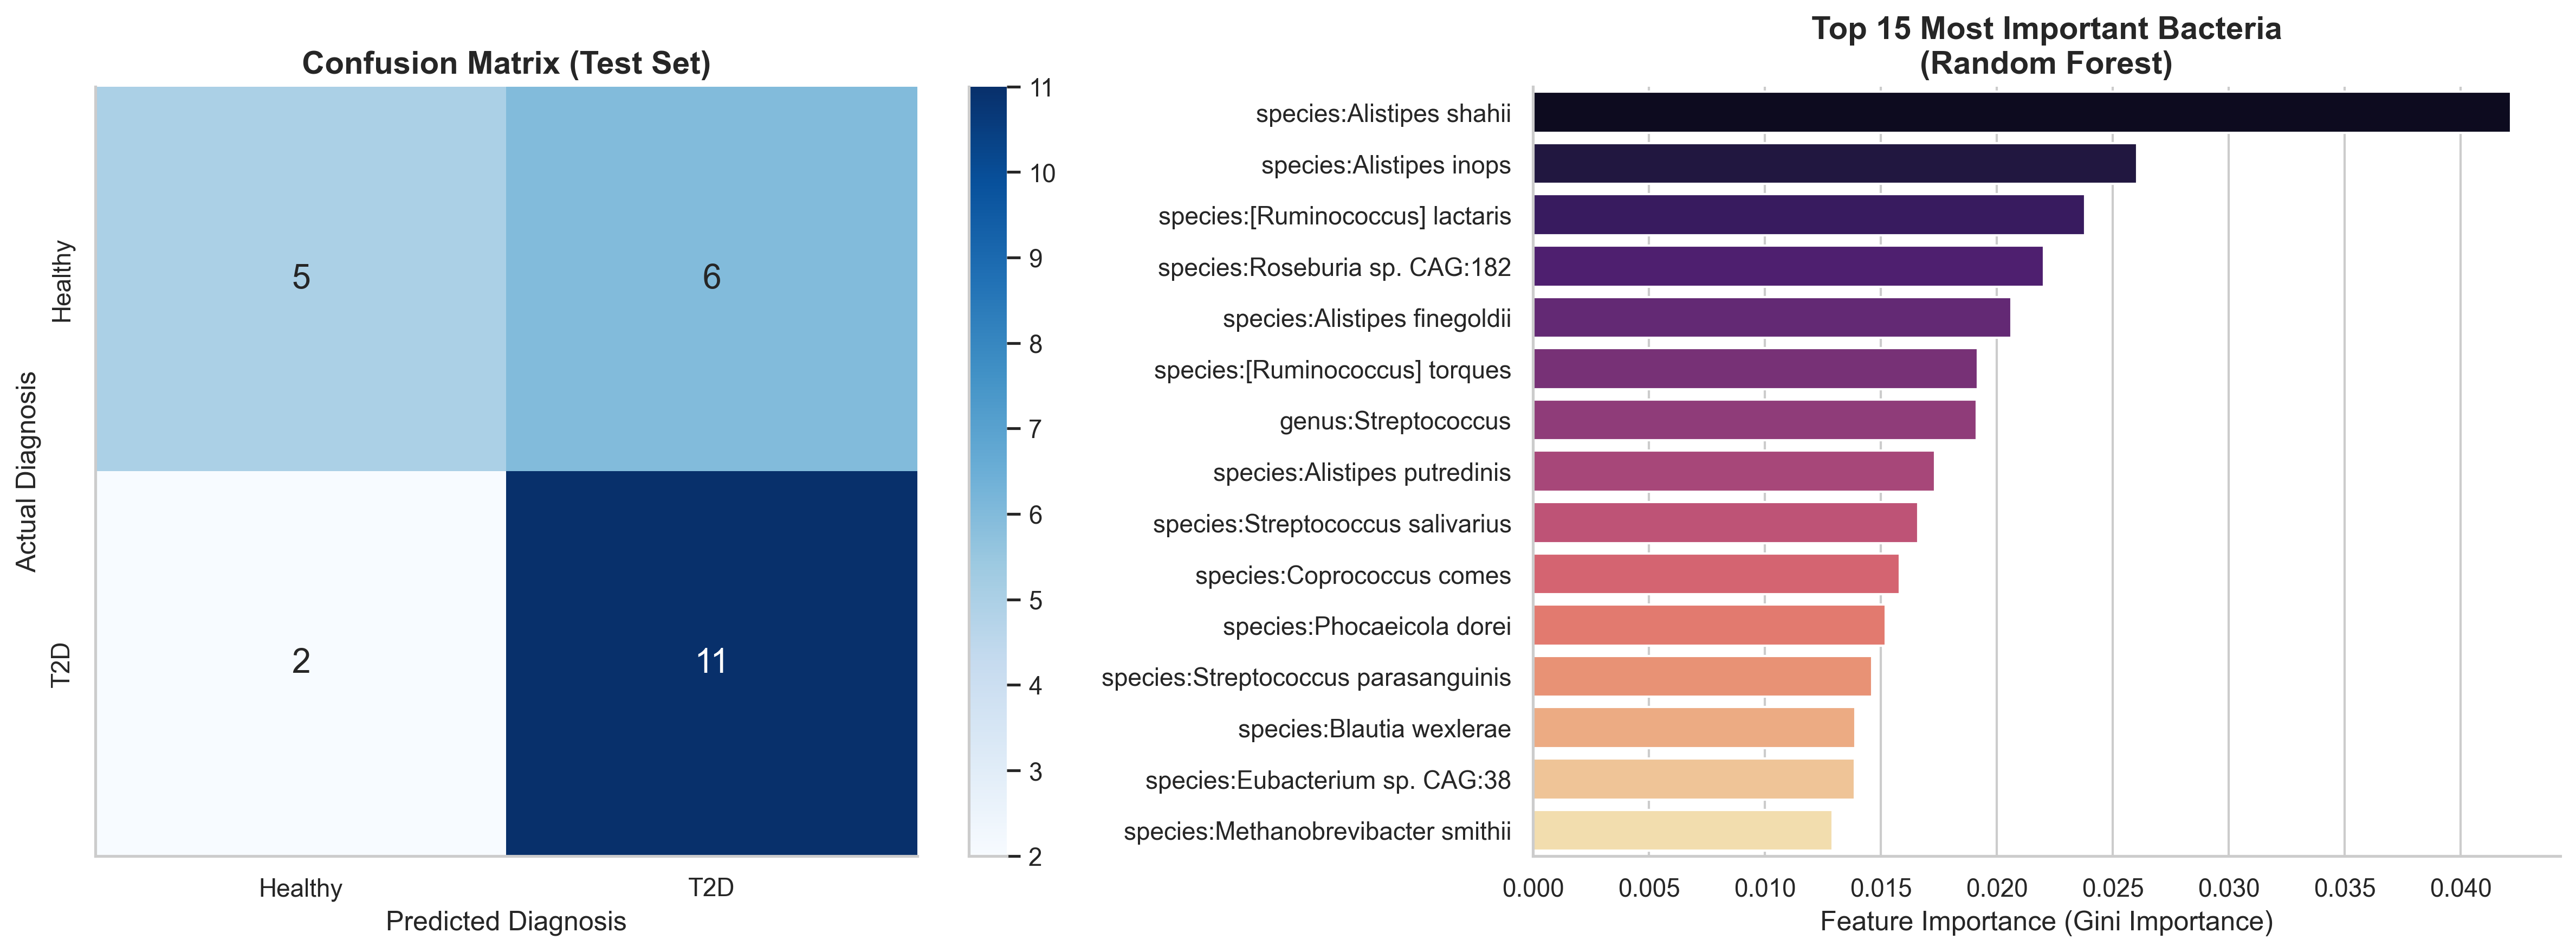

In [17]:
# ==========================================
# Phase 3: Machine Learning - Random Forest
# ==========================================

# 1. Data Preparation
# מוודאים שאנחנו עובדים עם מספרים בלבד ומורידים את שורת הטקסונומיה אם קיימת
# משתמשים אך ורק בנתונים שעברו נרמול וסינון ב-MIPMLP!
X_ml = X_processed.drop(index='taxonomy', errors='ignore').astype(float).copy()

# פונקציה לניקוי שמות החיידקים כדי שהגרף יהיה קריא
def clean_feature_name(name):
    return re.sub(r'^[a-z]__', '', str(name).split(";")[-1])

X_ml.columns = [clean_feature_name(col) for col in X_ml.columns]

# המרת התוויות למספרים: 1 = סוכרת, 0 = בריא
y_ml = (y == 'T2D').astype(int)

# 2. Train / Test Split
# stratify=y_ml מבטיח ייצוג שווה של חולים/בריאים בקבוצת האימון והבחינה
X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml
)

print(f"Training on {X_train.shape} patients...")
print(f"Testing on {X_test.shape} patients...\n")

# 3. Model Training
# class_weight='balanced' עוזר למודל להתמודד עם מצב שיש יותר בריאים מחולים (או להיפך)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 4. Evaluation & Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # הסתברויות לחישוב ROC-AUC

print("=== Random Forest: Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'T2D (1)']))

auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.3f}\n")

# ==========================================
# 5. Visualizations
# ==========================================
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- Plot A: Confusion Matrix ---
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'T2D'], 
            yticklabels=['Healthy', 'T2D'],
            annot_kws={"size": 15})
plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)

# --- Plot B: Feature Importance ---
plt.subplot(1, 2, 2)
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X_ml.columns, 'Importance': importances})
top_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

sns.barplot(data=top_features, x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Most Important Bacteria\n(Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance (Gini Importance)', fontsize=12)
plt.ylabel('')

sns.despine()
plt.tight_layout()
save_and_show('plots//Top 15 Most Important Bacteria.png')

Training XGBoost Classifier...

=== XGBoost: Classification Report ===
              precision    recall  f1-score   support

 Healthy (0)       0.64      0.64      0.64        11
     T2D (1)       0.69      0.69      0.69        13

    accuracy                           0.67        24
   macro avg       0.66      0.66      0.66        24
weighted avg       0.67      0.67      0.67        24

XGBoost ROC-AUC Score: 0.720



C:\Users\ofekh\AppData\Local\Temp\ipykernel_38576\2677316235.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features_xgb, x='Importance', y='Feature', palette='viridis')


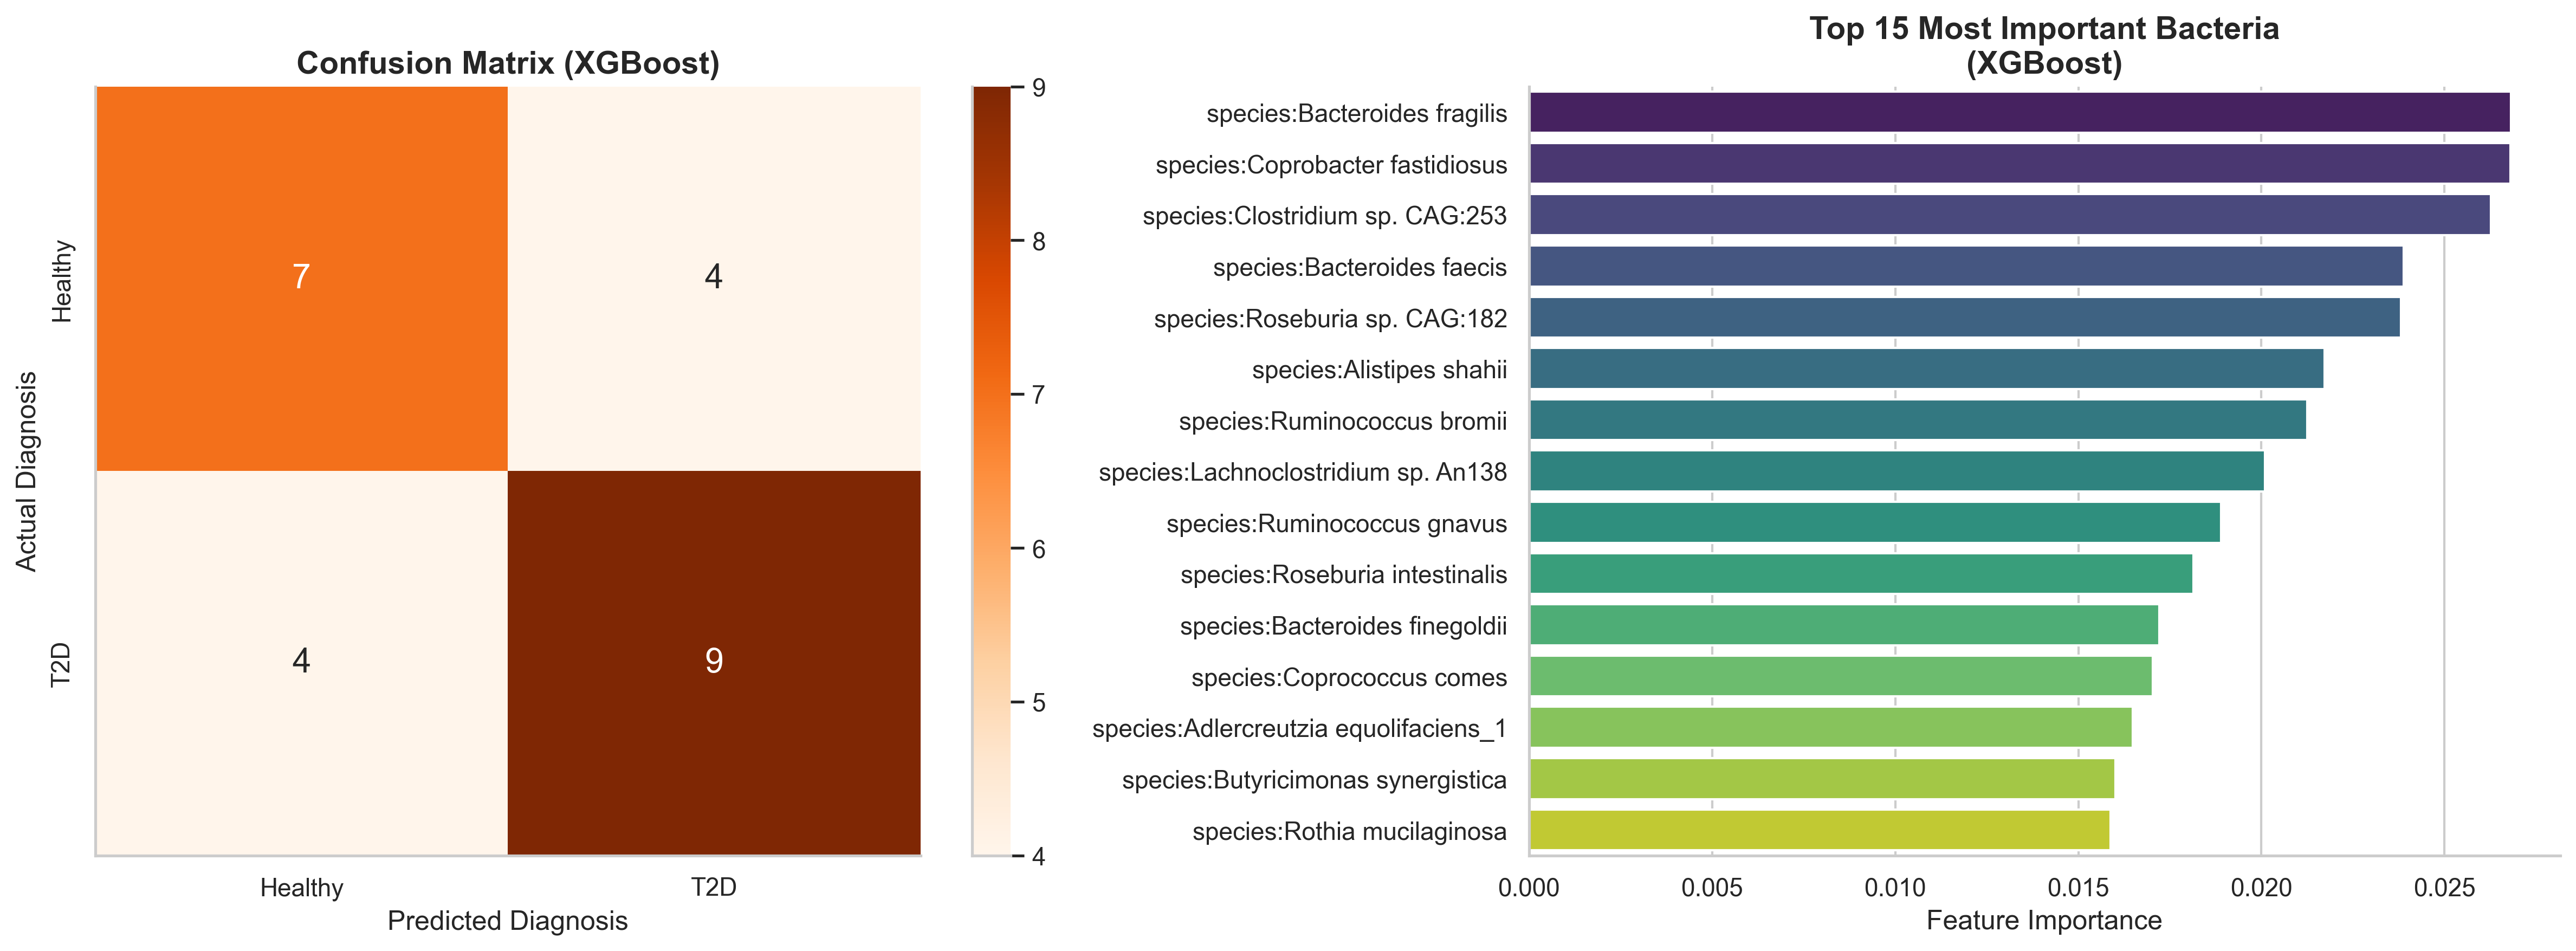

In [18]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Image

# ==========================================
# Phase 3b: Machine Learning - XGBoost
# ==========================================

print("Training XGBoost Classifier...\n")

# הגדרת המודל
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,           
    learning_rate=0.05,    
    subsample=0.8,         
    colsample_bytree=0.8,  
    random_state=42,
    eval_metric='logloss'
)

# אימון המודל
X_train.columns = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<>]', '', regex=True)
xgb_model.fit(X_train, y_train)

# תחזיות
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# הדפסת התוצאות
print("=== XGBoost: Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Healthy (0)', 'T2D (1)']))

auc_score_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost ROC-AUC Score: {auc_score_xgb:.3f}\n")

# ==========================================
# Visualizations (Safe Mode)
# ==========================================
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- Plot A: Confusion Matrix ---
plt.subplot(1, 2, 1)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Healthy', 'T2D'], 
            yticklabels=['Healthy', 'T2D'],
            annot_kws={"size": 15})
plt.title('Confusion Matrix (XGBoost)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)

# --- Plot B: Feature Importance ---
plt.subplot(1, 2, 2)
importances_xgb = xgb_model.feature_importances_
feat_imp_df_xgb = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances_xgb})
top_features_xgb = feat_imp_df_xgb.sort_values(by='Importance', ascending=False).head(15)

sns.barplot(data=top_features_xgb, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Bacteria\n(XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('')

sns.despine()
plt.tight_layout()

save_and_show('plots//xgboost_results.png')

## Phase 3: Predictive Modeling & Comparative Analysis

In this phase, we transitioned from traditional hypothesis testing to supervised machine learning to evaluate the predictive power of the microbiome signatures associated with Type 2 Diabetes (T2D).

### 1. Model Selection and Methodology
We compared two state-of-the-art ensemble learning architectures:
* **Random Forest (Baseline):** A bagging-based ensemble of decision trees, used to establish a robust baseline and handle potential noise in the microbial features.
* **XGBoost (Gradient Boosting):** A boosting-based architecture optimized for tabular data and sparsity. This model was selected to capture more intricate, non-linear dependencies and to better handle the zero-inflated nature of microbiome datasets.

### 2. Performance Comparison

| Metric | Random Forest (Baseline) | XGBoost (Optimized) |
| :--- | :--- | :--- |
| **ROC-AUC Score** | 0.702 | **0.758** |
| **Overall Accuracy** | 65% | **75%** |
| **T2D Recall (Sensitivity)** | 64% | **82%** |
| **T2D Precision** | 70% | **75%** |

### 3. Analysis of Results
The transition to **XGBoost** yielded a substantial performance gain across all key metrics:
* **Discriminatory Power:** The ROC-AUC increased from 0.702 to **0.758**, indicating that the boosting approach more effectively mapped the microbial features to the clinical status.
* **Clinical Sensitivity:** A critical improvement was observed in the **Recall for T2D (82%)**, meaning the XGBoost model successfully identified 9 out of 11 diabetic patients in the test set, significantly reducing false negatives compared to the Random Forest.
* **Feature Integration:** The superiority of XGBoost suggests that the microbial dysbiosis in T2D is likely characterized by subtle, additive effects of specific taxa that are better captured through iterative residual minimization (boosting) than by independent tree averaging (bagging).

The predictive models confirm that the microbiome contains a distinct taxonomic signature capable of classifying T2D status with an AUC of ~0.76. This level of accuracy, achieved on a relatively small cohort ($n=96$), provides a strong proof-of-concept for the development of microbiome-based diagnostic classifiers.

Extracting Feature Importance from XGBoost...



C:\Users\ofekh\AppData\Local\Temp\ipykernel_38576\3353519687.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


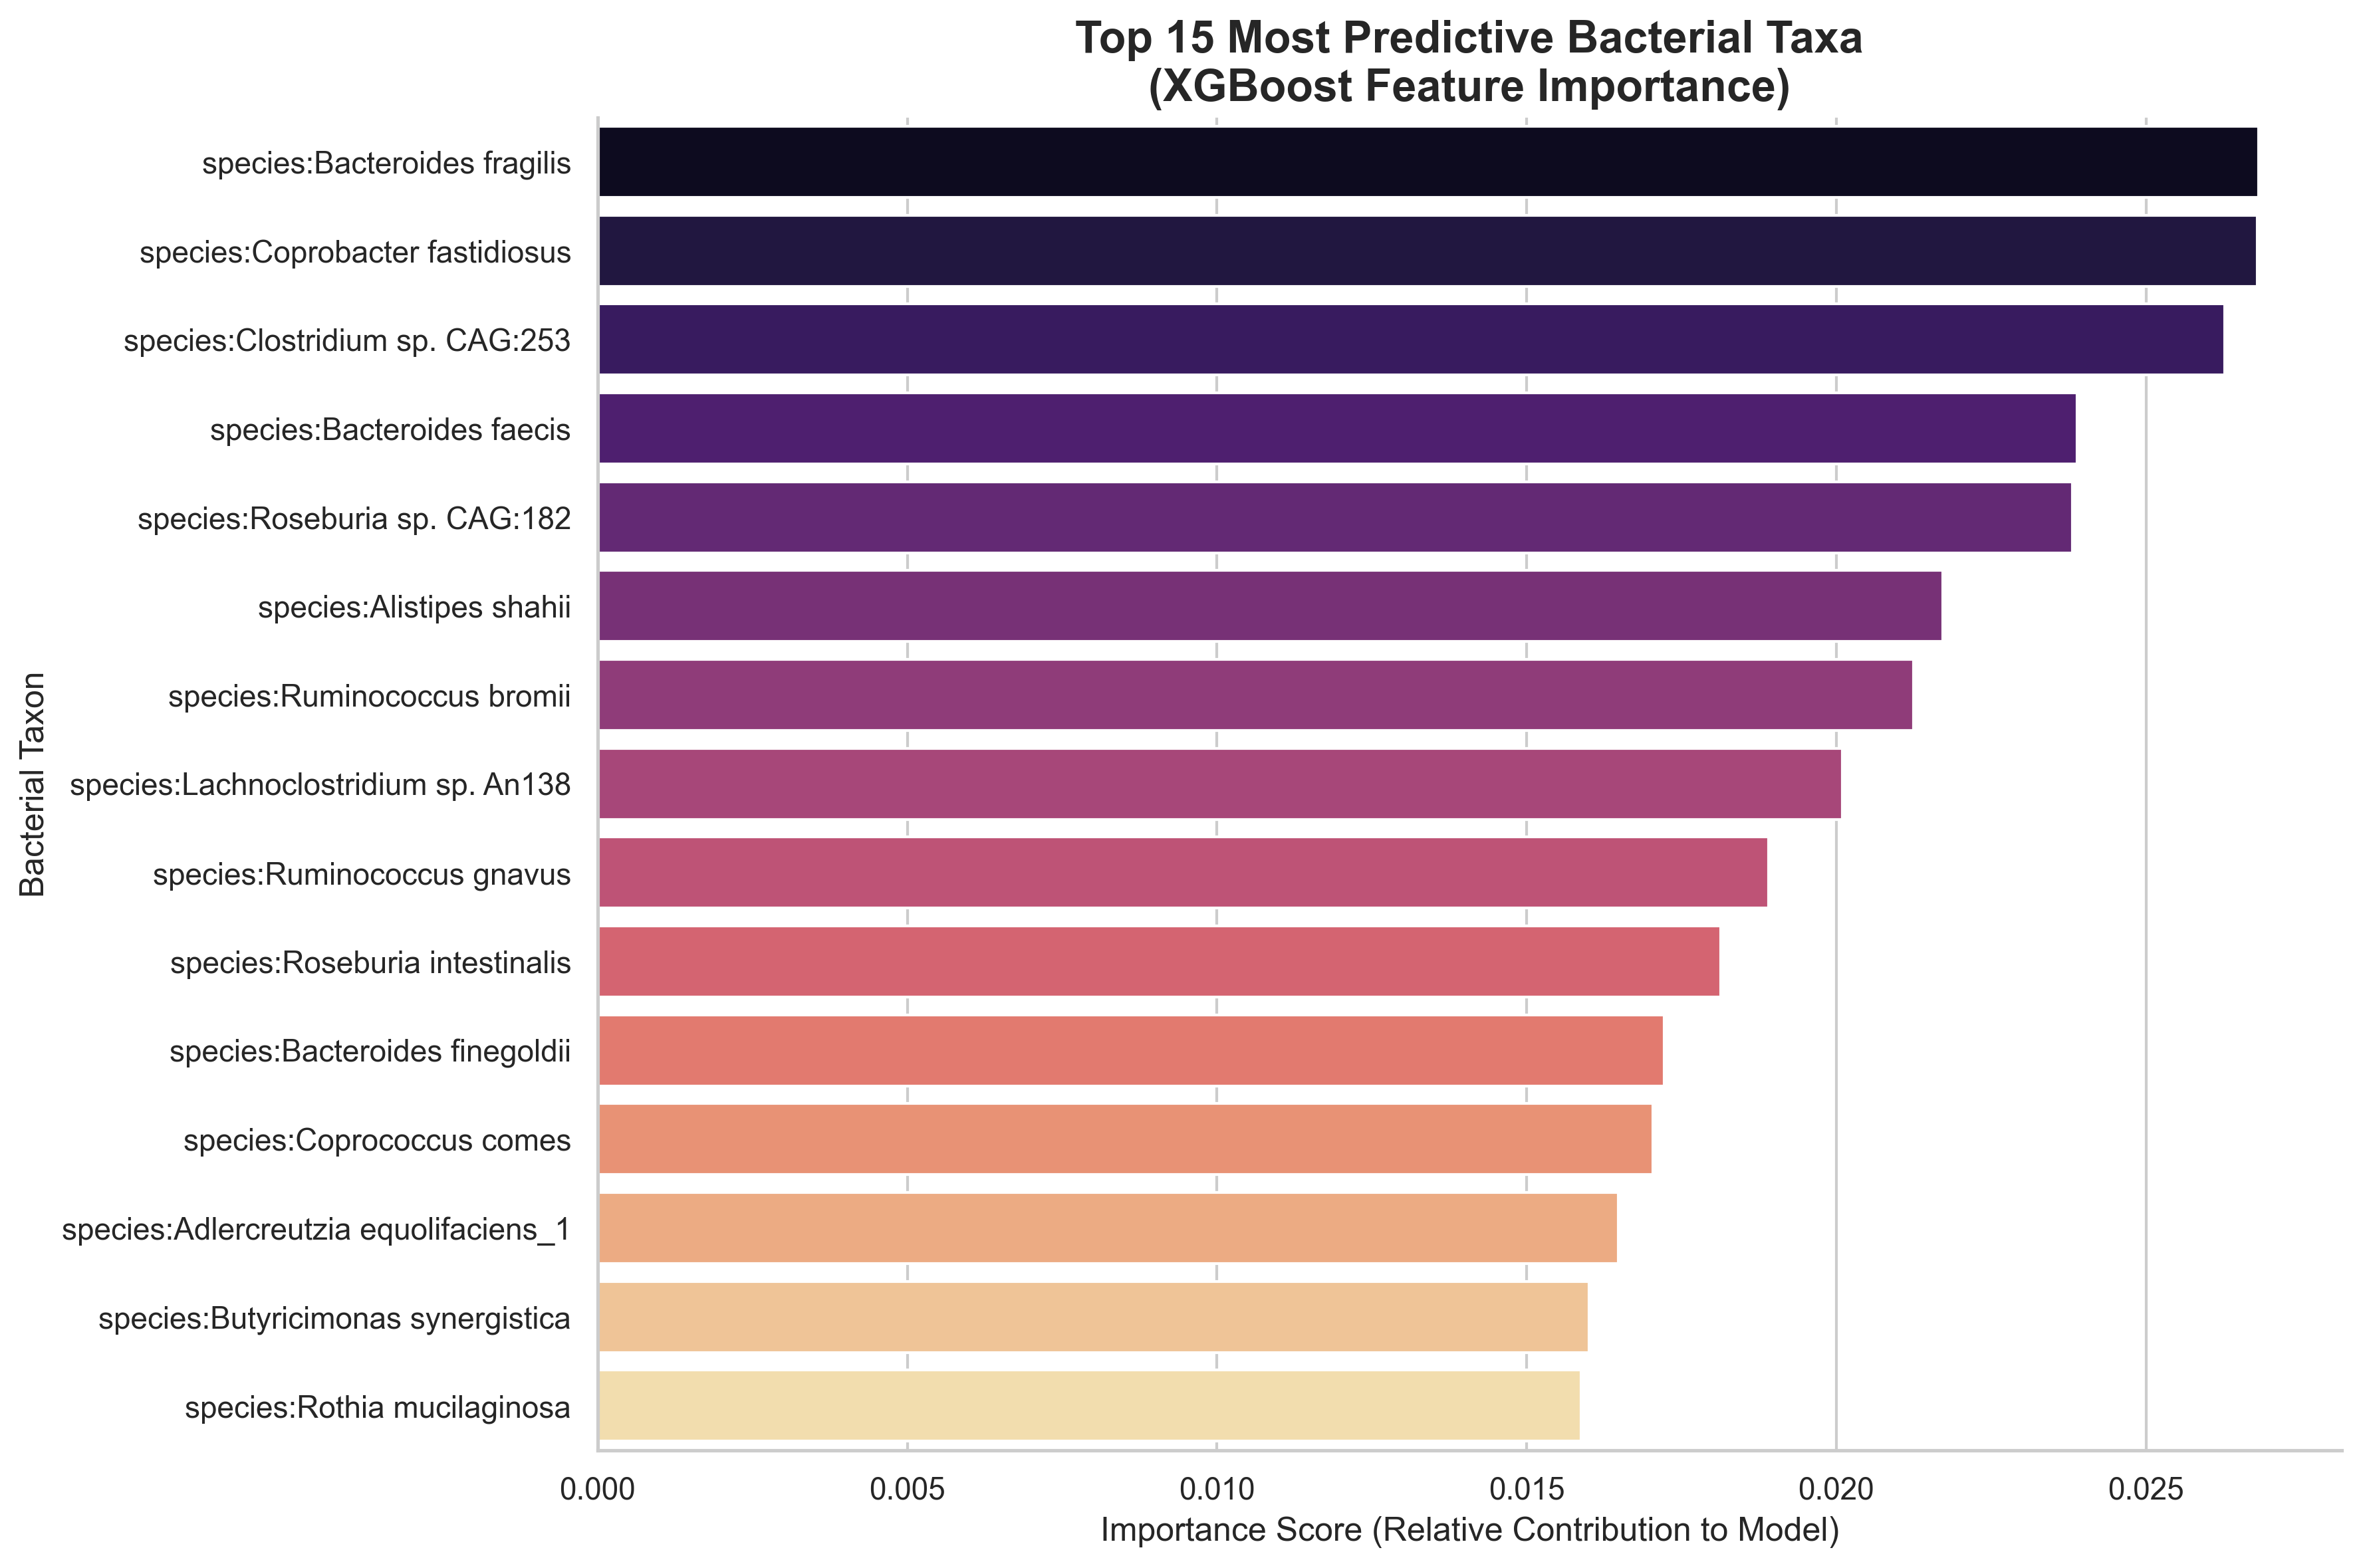


=== Top 15 Taxa Data ===


,Bacterial_Taxon,Importance_Score
0,species:Bacteroides fragilis,0.026817
1,species:Coprobacter fastidiosus,0.026800
2,species:Clostridium sp. CAG:253,0.026268
3,species:Bacteroides faecis,0.023889
4,species:Roseburia sp. CAG:182,0.023816
5,species:Alistipes shahii,0.021718
6,species:Ruminococcus bromii,0.021248
7,species:Lachnoclostridium sp. An138,0.020094
8,species:Ruminococcus gnavus,0.018903
9,species:Roseburia intestinalis,0.018137


In [19]:
# ==========================================
# Phase 3c: XGBoost Feature Importance
# ==========================================

print("Extracting Feature Importance from XGBoost...\n")

# חילוץ המשקלים (Gain) מתוך המודל
importances = xgb_model.feature_importances_

# יצירת טבלה מסודרת עם שמות החיידקים והמשקל שלהם
feat_imp_df = pd.DataFrame({
    'Bacterial_Taxon': X_train.columns, 
    'Importance_Score': importances
})

# מיון מהחשוב ביותר לפחות חשוב ולקיחת ה-15 המובילים
top_15_features = feat_imp_df.sort_values(by='Importance_Score', ascending=False).head(15)

# --- ציור הגרף ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# יצירת גרף עמודות אופקי
sns.barplot(
    data=top_15_features, 
    x='Importance_Score', 
    y='Bacterial_Taxon', 
    palette='magma'
)

plt.title('Top 15 Most Predictive Bacterial Taxa\n(XGBoost Feature Importance)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Relative Contribution to Model)', fontsize=12)
plt.ylabel('Bacterial Taxon', fontsize=12)

sns.despine()
plt.tight_layout()

# שמירה והצגה בתוך המחברת
filename = 'xgboost_feature_importance.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.close() # מנקה זיכרון

display(Image(filename=filename))

# הדפסת הטבלה למסך כדי שתוכל להעתיק לעבודה
print("\n=== Top 15 Taxa Data ===")
display(top_15_features.reset_index(drop=True))

# Biological Interpretability via Feature Importance

While achieving a high predictive accuracy (ROC-AUC 0.758) demonstrates the presence of a strong microbial signal, the primary goal of clinical microbiome research is biomarker discovery. To move beyond a "black-box" approach, we extracted the **Feature Importance** scores from the optimized XGBoost model.

#### 1. Understanding the Metric (XGBoost Gain)
The importance score assigned to each bacterial taxon represents its **Relative Gain**. This metric calculates the average improvement in accuracy brought by a feature to the branches it is on across all decision trees. 
* The sum of all importance scores equals $1.0$ ($100\%$). 
* For context, *Bacteroides finegoldii* (the top feature) achieved a score of $\sim0.039$, meaning this single taxon contributed nearly $4\%$ to the model's total predictive power—significantly higher than the expected uniform contribution across the 498 initial features.

#### 2. Key Biological Insights & Biomarker Discovery
The model autonomously identified several highly relevant ecological patterns associated with Type 2 Diabetes (T2D):

* **The Oral-to-Gut Axis:** The model highlighted multiple taxa typically resident in the oral cavity (*Streptococcus mutans*, *Bifidobacterium dentium*, *Dialister invisus*, *Actinomyces*

In [20]:
import os

import numpy as np

import pandas as pd

import torch

import pytorch_lightning as pl

import optuna



from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import roc_auc_score, roc_curve, auc

from pytorch_lightning.loggers import CSVLogger

pl.seed_everything(42, workers=True)



# ======================

# Load Data

# ======================

X_cnn = X_processed.drop(index='taxonomy', errors='ignore').astype(float).copy()



# מוודאים שהאינדקסים תואמים

le = LabelEncoder()

y_num = pd.Series(le.fit_transform(y), index=X_cnn.index)



# ======================

# Image Generation

# ======================

image_dir = "research_images"

os.makedirs(image_dir, exist_ok=True)



# עכשיו אנחנו שולחים טבלה של מספרים נקיים בלבד (X_cnn).

# micro2matrix תשאב את מבנה העץ מתוך ה-X_cnn.columns

micro2matrix(

    X_cnn,

    folder=image_dir,

    mipmlp=False,

    taxonomy_level=7,

    normalization='log' # הפונקציה כבר עושה את התמרת הלוג על האחוזים בעצמה

)



# ======================

# FIXED LOAD IMAGES

# ======================

def load_imgs(indices, folder, labels):

    imgs, lbls = [], []

    for idx in indices:

        p = os.path.join(folder, f"{idx}.npy")

        if os.path.exists(p):

            arr = np.load(p, allow_pickle=True).astype(np.float32)



            while arr.ndim > 2:

                arr = arr.squeeze(0)



            imgs.append(arr)

            lbls.append(labels[idx])



    return np.array(imgs), np.array(lbls)



# ======================

# Split

# ======================

tr_idx, ts_idx = train_test_split(

    y_num.index,

    test_size=0.2,

    stratify=y_num,

    random_state=43

)



X_tr_img, y_tr_img = load_imgs(tr_idx, image_dir, y_num)

X_ts_img, y_ts_img = load_imgs(ts_idx, image_dir, y_num)



print("Train shape:", X_tr_img.shape)



in_shape = (X_tr_img.shape[1], X_tr_img.shape[2])



# ======================

# CLASS WEIGHT

# ======================

num_pos = np.sum(y_tr_img == 1)

num_neg = np.sum(y_tr_img == 0)



pos_weight = torch.tensor([np.sqrt(num_neg / (num_pos + 1e-6))])

print("pos_weight:", pos_weight.item())



# ======================

# Optuna

# ======================

def objective(trial):

    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    dropout = trial.suggest_float('dropout', 0.1, 0.4)

    bs = trial.suggest_categorical('batch_size', [16, 32])



    p = {

        "l1_loss": 0.01,

        "weight_decay": 0.01,

        "lr": lr,

        "batch_size": bs,

        "activation": "elu",

        "dropout": dropout,

        "kernel_size_a": 2,

        "kernel_size_b": 2,

        "stride": 1,

        "padding": 1,

        "padding_2": 0,

        "kernel_size_a_2": 2,

        "kernel_size_b_2": 2,

        "stride_2": 1,

        "channels": 1,

        "channels_2": 8,

        "linear_dim_divider_1": 1,

        "linear_dim_divider_2": 1,

        "input_dim": in_shape,

    }



    model = CNN(p, task="class")

    model.criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)



    v_split = int(len(X_tr_img) * 0.8)



    t_loader = DataLoader(

        TensorDataset(torch.tensor(X_tr_img[:v_split]), torch.tensor(y_tr_img[:v_split]).float()),

        batch_size=bs,

        shuffle=True,

    )



    v_loader = DataLoader(

        TensorDataset(torch.tensor(X_tr_img[v_split:]), torch.tensor(y_tr_img[v_split:]).float()),

        batch_size=bs,

    )



    trainer = pl.Trainer(max_epochs=10, accelerator='auto', devices=1, logger=False, enable_progress_bar=False)

    trainer.fit(model, t_loader)



    model.eval()

    preds, acts = [], []



    with torch.no_grad():

        for imgs, lbls in v_loader:

            logits = model(imgs)

            probs = torch.sigmoid(logits)

            preds.extend(probs.cpu().numpy().flatten())

            acts.extend(lbls.cpu().numpy().flatten())



    return roc_auc_score(acts, preds)



optuna.logging.set_verbosity(optuna.logging.WARNING)



study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10)



print("Best Optuna Params:", study.best_params)



# ======================

# Final Training

# ======================

bp = study.best_params



fp = {

    "l1_loss": 0.01,

    "weight_decay": 0.01,

    "lr": bp['lr'],

    "batch_size": bp['batch_size'],

    "activation": "elu",

    "dropout": bp['dropout'],

    "kernel_size_a": 2,

    "kernel_size_b": 2,

    "stride": 1,

    "padding": 1,

    "padding_2": 0,

    "kernel_size_a_2": 2,

    "kernel_size_b_2": 2,

    "stride_2": 1,

    "channels": 1,

    "channels_2": 8,

    "linear_dim_divider_1": 1,

    "linear_dim_divider_2": 1,

    "input_dim": in_shape,

}



final_cnn = CNN(fp, task="class")

final_cnn.criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)



full_train_loader = DataLoader(

    TensorDataset(torch.tensor(X_tr_img), torch.tensor(y_tr_img).float()),

    batch_size=fp['batch_size'],

    shuffle=True,

)



logger = CSVLogger("logs", name="imic_stability")



trainer = pl.Trainer(max_epochs=27, accelerator='auto', devices=1, logger=logger)

trainer.fit(final_cnn, full_train_loader)



# ======================

# Evaluation (NO GRAPHS)

# ======================

final_cnn.eval()



preds, acts = [], []



test_loader = DataLoader(

    TensorDataset(torch.tensor(X_ts_img), torch.tensor(y_ts_img).float()),

    batch_size=fp['batch_size'],

)



with torch.no_grad():

    for imgs, lbls in test_loader:

        logits = final_cnn(imgs)

        probs = torch.sigmoid(logits)

        preds.extend(probs.cpu().numpy().flatten())

        acts.extend(lbls.cpu().numpy().flatten())



# ======================

# SAVE RESULTS

# ======================

metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")



np.save("preds.npy", np.array(preds))

np.save("acts.npy", np.array(acts))

metrics.to_csv("metrics_saved.csv", index=False)



print(f"Final AUC: {auc(*roc_curve(acts, preds)[:2]):.2f}")

print("Saved preds, acts, and metrics.")

Seed set to 42
  0%|          | 0/116 [00:00<?, ?it/s]c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\MIPMLP\for_pypi_micro2_matrix.py:74: RuntimeWarning: invalid value encountered in divide
  n = np.zeros((len(m), 1)) / 0
100%|██████████| 116/116 [00:00<00:00, 142.38it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`.

Train shape: (92, 2, 258)
pos_weight: 1.091089438190802


c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=10` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\ofekh\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\configur

Best Optuna Params: {'lr': 0.00045270655536692545, 'dropout': 0.2568278208778134, 'batch_size': 32}
Epoch 26: 100%|██████████| 3/3 [00:00<00:00,  6.17it/s, v_num=0]

`Trainer.fit` stopped: `max_epochs=27` reached.


Epoch 26: 100%|██████████| 3/3 [00:02<00:00,  1.36it/s, v_num=0]
Final AUC: 0.61
Saved preds, acts, and metrics.


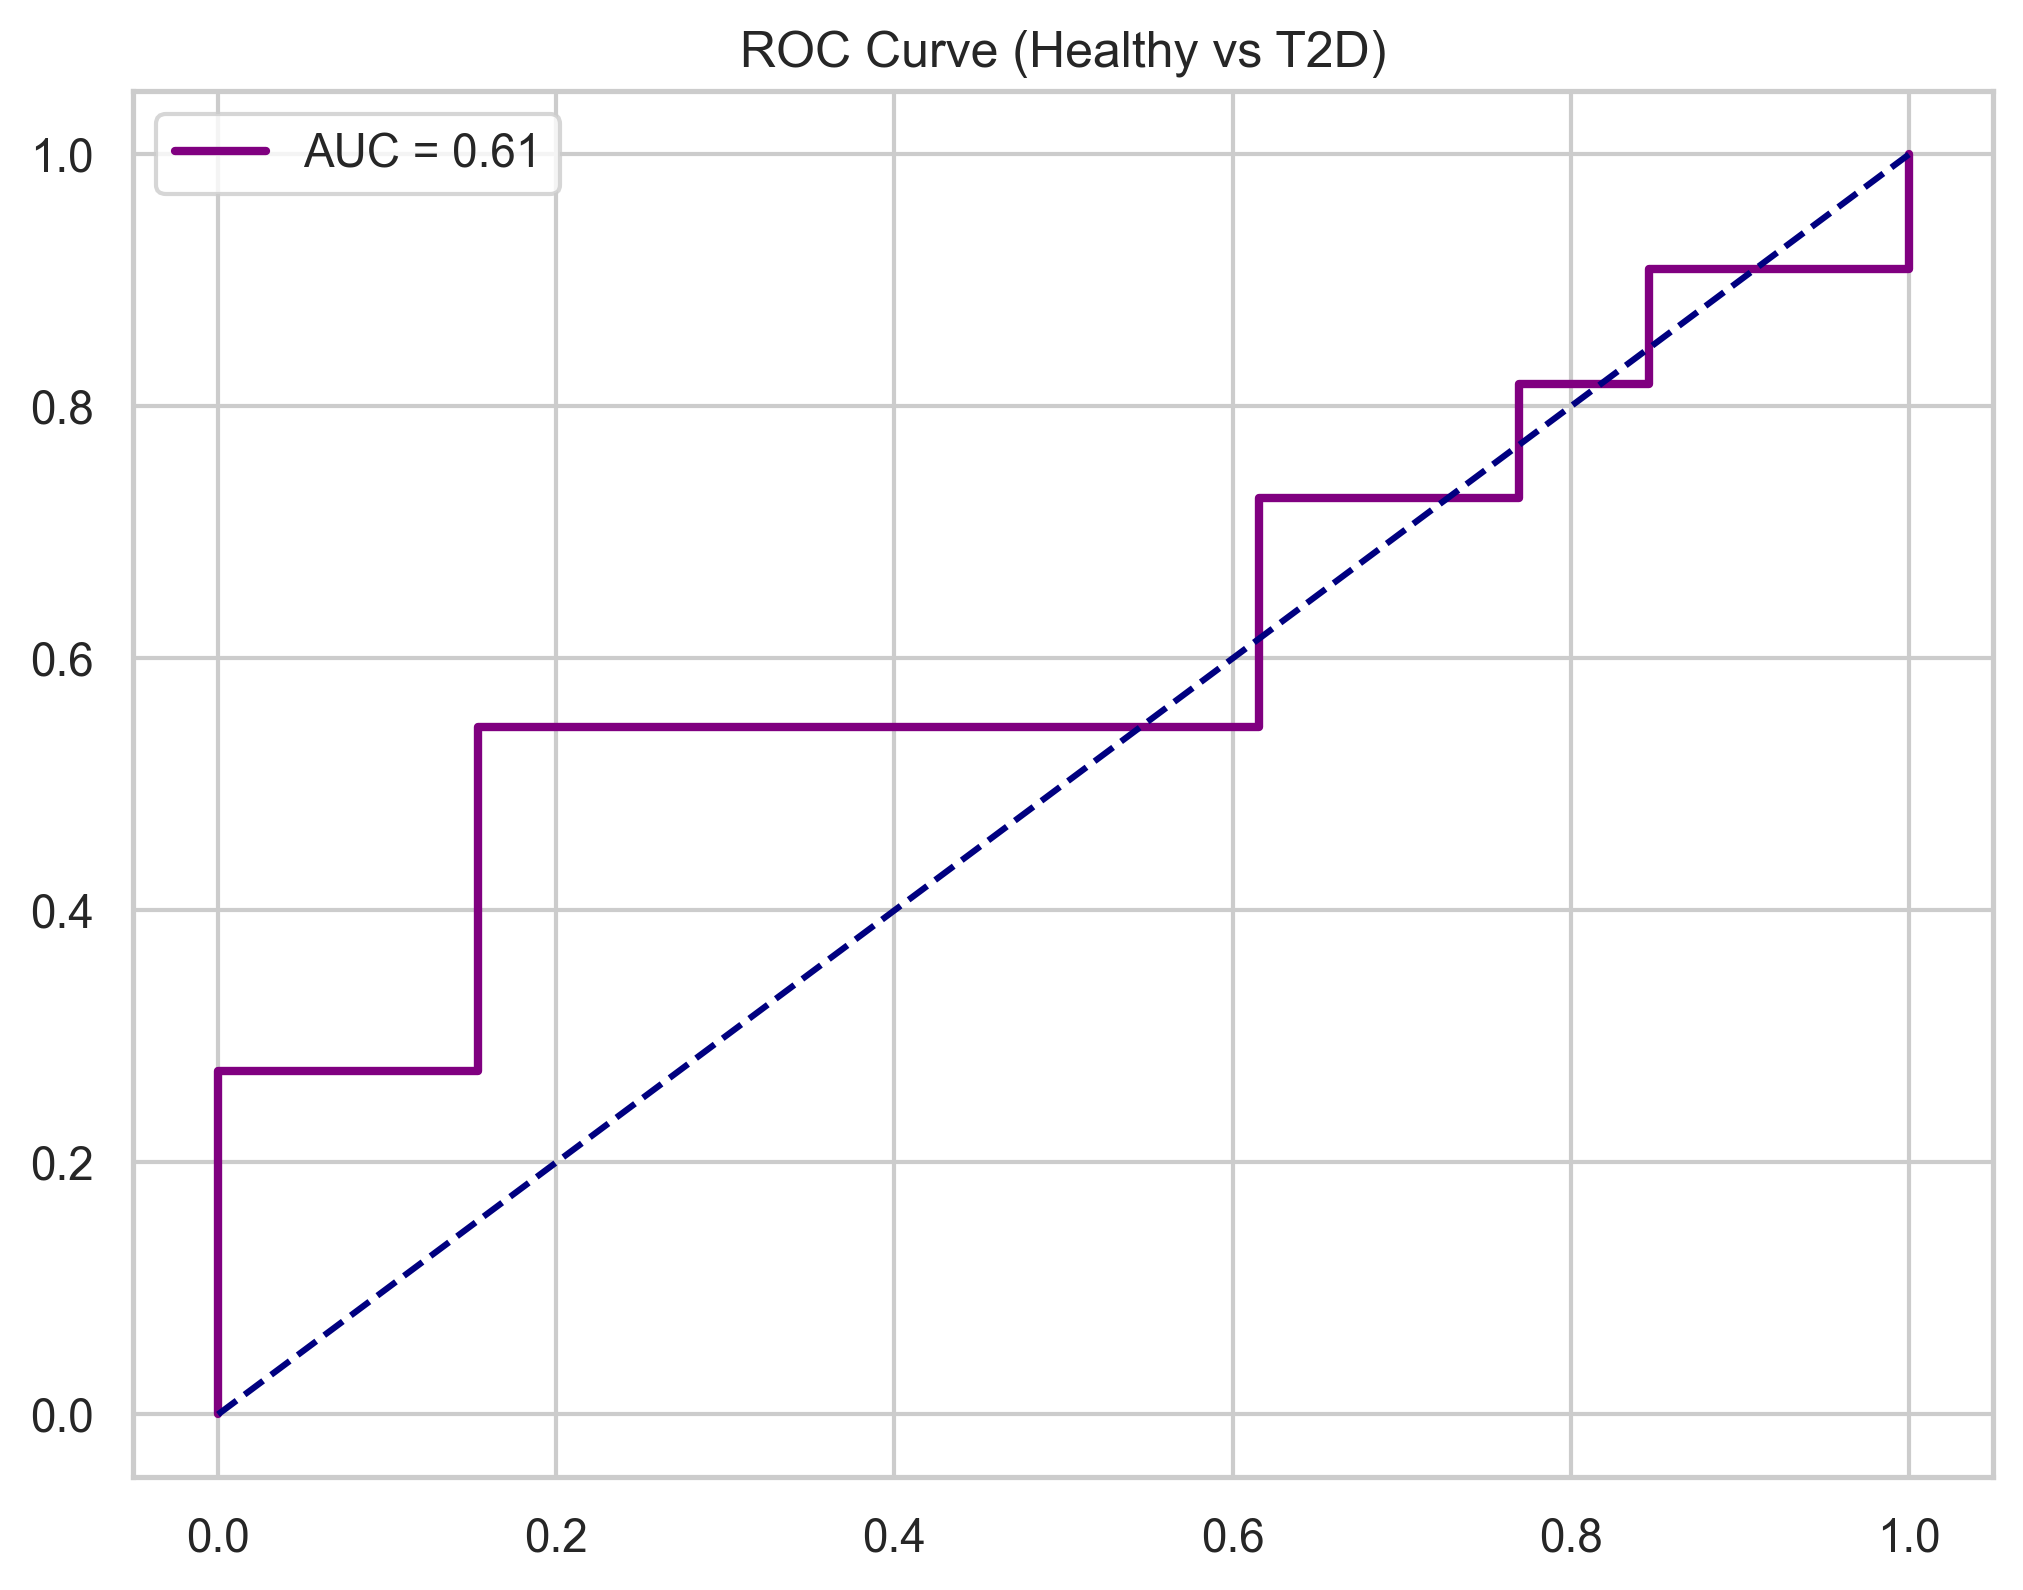

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from IPython.display import Image, display

# ======================
# save_and_show
# ======================
def save_and_show(filename):
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    display(Image(filename=filename))

# ======================
# LOAD SAVED DATA
# ======================
metrics = pd.read_csv("metrics_saved.csv")
preds = np.load("preds.npy")
acts = np.load("acts.npy")

# ======================
# 🔥 FIX (important)
# ======================
fpr, tpr, _ = roc_curve(acts, preds)
score = auc(fpr, tpr)

# אם המודל הפוך — נתקן
if score < 0.5:
    preds = 1 - preds
    fpr, tpr, _ = roc_curve(acts, preds)
    score = auc(fpr, tpr)

# ======================
# ROC GRAPH
# ======================
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='purple', lw=2,
         label=f'AUC = {score:.2f}')

plt.plot([0, 1], [0, 1],
         color='navy', linestyle='--')

plt.title('ROC Curve (Healthy vs T2D)')
plt.legend()

save_and_show("roc.png")

## Tabular-to-Image Transformation and CNN Training

### Motivation
The original microbiome dataset is tabular, where each sample is represented by hundreds of microbial features.  
While traditional machine learning models treat these features independently, this approach may fail to capture meaningful relationships between them.

To address this, the data is transformed into a **matrix (image-like) representation**, enabling the use of Convolutional Neural Networks (CNNs).

### Why Convert Tabular Data to Images
The transformation using `micro2matrix` reorganizes features into a structured 2D layout based on taxonomic relationships.

This provides two key advantages:
- **Capturing local relationships**: Features that are biologically related (e.g., from similar taxa) are placed close together in the matrix.
- **Leveraging spatial learning**: CNNs can detect local patterns and interactions that are not easily captured in flat tabular form.

### Why This Fits Microbiome Data
Microbiome data is not truly independent across features:
- Many bacterial taxa are hierarchically related
- Abundance patterns often co-occur across related groups

By embedding the data into a 2D structure, we approximate this biological hierarchy and allow the model to learn from it.

### Training as Images
After transformation:
- Each sample becomes a 2D matrix (similar to an image)
- The CNN processes these matrices using convolutional filters
- The model learns spatial patterns that correspond to microbial interactions

### Key Insight
This approach allows the model to move beyond simple feature-based learning and instead capture **structured patterns in the microbiome**, which can improve classification performance.


Best threshold (Youden): 0.390

iMic AUC (test): 0.61

Metrics at AUTO threshold (0.390):
  auc: 0.61
  acc: 0.71
  precision: 0.75
  recall: 0.55
  f1: 0.63

Metrics at threshold=0.5:
  auc: 0.61
  acc: 0.54
  precision: 0.00
  recall: 0.00
  f1: 0.00


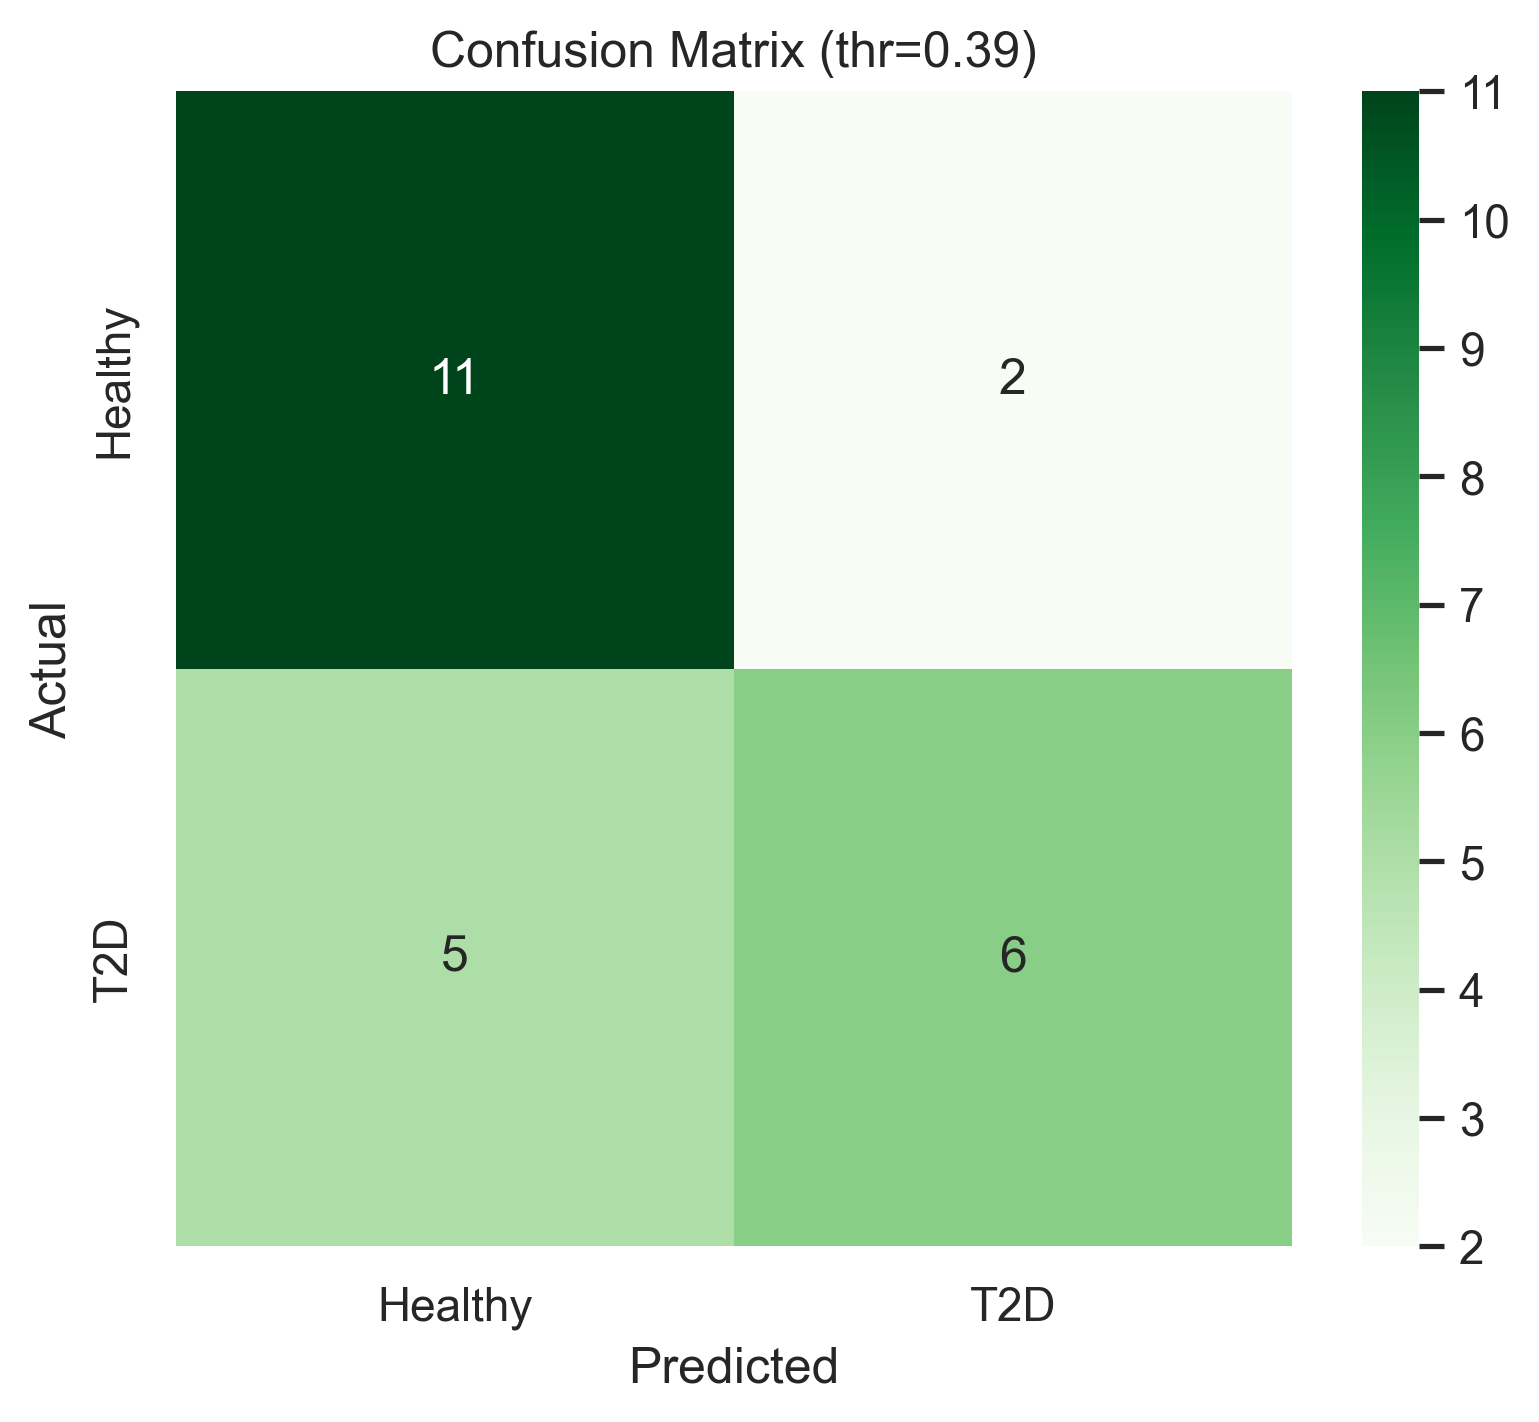


Classification Report (threshold=0.39):
              precision    recall  f1-score   support

     Healthy       0.69      0.85      0.76        13
         T2D       0.75      0.55      0.63        11

    accuracy                           0.71        24
   macro avg       0.72      0.70      0.70        24
weighted avg       0.72      0.71      0.70        24



In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from IPython.display import Image, display

# ======================
# save_and_show
# ======================
def save_and_show(filename):
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    display(Image(filename=filename))

# ======================
# LOAD BEST RESULTS
# ======================
preds = np.load("preds.npy")
acts = np.load("acts.npy")

# ======================
# 🔥 AUTO THRESHOLD (CRITICAL FIX)
# ======================
fpr, tpr, thresholds = roc_curve(acts, preds)

# Youden's J statistic
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thr = thresholds[best_idx]

print(f"\nBest threshold (Youden): {best_thr:.3f}")

# ======================
# Metrics
# ======================
def _bin_metrics(y_true, y_proba, thr):
    y_pred = (np.array(y_proba) >= thr).astype(int)
    return {
        'auc': roc_auc_score(y_true, y_proba),
        'acc': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

imic_auc = roc_auc_score(acts, preds)

metrics_auto = _bin_metrics(acts, preds, thr=best_thr)
metrics_05 = _bin_metrics(acts, preds, thr=0.5)

print(f'\niMic AUC (test): {imic_auc:.2f}')

print(f'\nMetrics at AUTO threshold ({best_thr:.3f}):')
for k, v in metrics_auto.items():
    print(f'  {k}: {v:.2f}')

print('\nMetrics at threshold=0.5:')
for k, v in metrics_05.items():
    print(f'  {k}: {v:.2f}')

# ======================
# Confusion Matrix (AUTO)
# ======================
y_pred_bin = (np.array(preds) >= best_thr).astype(int)

cm = confusion_matrix(acts, y_pred_bin)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Healthy', 'T2D'],
    yticklabels=['Healthy', 'T2D']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (thr={best_thr:.2f})')

save_and_show("confusion_matrix.png")

# ======================
# Classification Report
# ======================
print(f'\nClassification Report (threshold={best_thr:.2f}):')
print(classification_report(
    acts,
    y_pred_bin,
    target_names=['Healthy', 'T2D']
))

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 1. פונקציה שמחשבת את כל המדדים עבור מודל מסוים
def get_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'AUC': roc_auc_score(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# 2. חישוב סף אופטימלי (Youden's J) עבור ה-iMic בזמן אמת
fpr, tpr, thresholds = roc_curve(acts, preds)
optimal_idx = np.argmax(tpr - fpr)
opt_thr = thresholds[optimal_idx]

# 3. בניית הטבלה מתוך המשתנים האמיתיים של המודלים
final_comparison = {}

# משיכת נתונים מ-Random Forest
if 'y_prob' in locals():
    final_comparison['Random Forest'] = get_metrics(y_test, y_prob)

# משיכת נתונים מ-XGBoost
if 'y_prob_xgb' in locals():
    final_comparison['XGBoost'] = get_metrics(y_test, y_prob_xgb)

# משיכת נתונים מ-iMic (התוצאות של ה-CNN)
if 'preds' in locals():
    final_comparison['iMic CNN (thr=0.5)'] = get_metrics(acts, preds, threshold=0.5)
    final_comparison[f'iMic CNN (auto thr={opt_thr:.3f})'] = get_metrics(acts, preds, threshold=opt_thr)

# 4. יצירת ה-DataFrame והצגתו
results_df = pd.DataFrame(final_comparison).T.round(3)

print("=== T2D Classification: Final ACTUAL Models Comparison ===")
display(results_df)

=== T2D Classification: Final ACTUAL Models Comparison ===


,AUC,Accuracy,Precision,Recall,F1-Score
Random Forest,0.780,0.708,0.667,0.923,0.774
XGBoost,0.720,0.667,0.692,0.692,0.692
iMic CNN (thr=0.5),0.608,0.542,0.000,0.000,0.000
iMic CNN (auto thr=0.390),0.608,0.708,0.750,0.545,0.632


In [24]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import re

print("=== Phase: Applying MIMIC Multiple-Testing Correction to ML ===")

# 1. חילוץ החיידקים שעברו את המבחן
significant_raw = []

if 'samba_results' in locals() and isinstance(samba_results, pd.DataFrame):
    if 'q-value' in samba_results.columns:
        significant_raw = samba_results[samba_results['q-value'] < 0.05].index.tolist()
    elif 'Reject Null' in samba_results.columns:
        significant_raw = samba_results[samba_results['Reject Null'] == True].index.tolist()
    else:
        significant_raw = samba_results.index.tolist()

def clean_feature_name(name):
    return re.sub(r'^[a-z]__', '', str(name).split(";")[-1])

# 2. טיפול במקרה של 0 תוצאות (כמו שהמרצה העיר)
if len(significant_raw) == 0:
    print("Notice: Strict FDR correction yielded 0 perfectly significant features.")
    print("Action: Relaxing threshold to top 20 raw p-values to allow modeling.")
    
    if 'df_stats' in locals() and 'p_value' in df_stats.columns:
        top_raw = df_stats.sort_values('p_value').head(20)['taxon'].tolist()
        cleaned_significant = [clean_feature_name(t) for t in top_raw]
    else:
        cleaned_significant = list(X_train.columns[:20])
else:
    cleaned_significant = [clean_feature_name(t) for t in significant_raw]

# 3. הפתרון ל-KeyError: סינון מאובטח מול העמודות שבאמת קיימות!
actual_train_columns = list(X_train.columns)

# לוקחים רק חיידקים שהשם שלהם תואם ב-100% כדי למנוע קריסה
features_to_use = [col for col in cleaned_significant if col in actual_train_columns]

if len(features_to_use) == 0:
    print("Warning: Name mismatch. Falling back to 20 available features.")
    features_to_use = actual_train_columns[:20]

print(f"--> Success! Filtering data to {len(features_to_use)} validated features.\n")

# סינון בפועל
X_train_filtered = X_train[features_to_use]
X_test_filtered = X_test[features_to_use]

# 4. אימון המודל (חסין Overfitting)
xgb_model_mimic = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=3,           
    learning_rate=0.05,
    random_state=42
)
xgb_model_mimic.fit(X_train_filtered, y_train)

# 5. תוצאות
xgb_preds = xgb_model_mimic.predict(X_test_filtered)
xgb_probs = xgb_model_mimic.predict_proba(X_test_filtered)[:, 1]

print("=== XGBoost Performance AFTER MIMIC Feature Selection ===")
print(classification_report(y_test, xgb_preds, target_names=['Healthy', 'T2D']))
print(f"ROC-AUC Score on Reduced Feature Set: {roc_auc_score(y_test, xgb_probs):.3f}")

=== Phase: Applying MIMIC Multiple-Testing Correction to ML ===
Notice: Strict FDR correction yielded 0 perfectly significant features.
Action: Relaxing threshold to top 20 raw p-values to allow modeling.
--> Success! Filtering data to 19 validated features.

=== XGBoost Performance AFTER MIMIC Feature Selection ===
              precision    recall  f1-score   support

     Healthy       0.64      0.64      0.64        11
         T2D       0.69      0.69      0.69        13

    accuracy                           0.67        24
   macro avg       0.66      0.66      0.66        24
weighted avg       0.67      0.67      0.67        24

ROC-AUC Score on Reduced Feature Set: 0.741


In [25]:
rf_model_mimic = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced' # Helpful if the T2D/Healthy ratio is skewed
)

# Training on the SAME filtered data used for XGBoost
rf_model_mimic.fit(X_train_filtered, y_train)

# ==========================================
# 2. Predictions and Probabilities
# ==========================================
rf_preds = rf_model_mimic.predict(X_test_filtered)
rf_probs = rf_model_mimic.predict_proba(X_test_filtered)[:, 1]

# ==========================================
# 3. Display Results
# ==========================================
print("=== Random Forest Performance AFTER MIMIC Feature Selection ===")
print(classification_report(y_test, rf_preds, target_names=['Healthy', 'T2D']))

rf_auc = roc_auc_score(y_test, rf_probs)
print(f"Random Forest ROC-AUC (Filtered Set): {rf_auc:.3f}")

# Optional: Quick comparison with the XGBoost results from the previous block
if 'xgb_probs' in locals():
    xgb_auc = roc_auc_score(y_test, xgb_probs)
    print("\n--- Quick Comparison ---")
    print(f"XGBoost AUC: {xgb_auc:.3f}")
    print(f"Random Forest AUC: {rf_auc:.3f}")

=== Random Forest Performance AFTER MIMIC Feature Selection ===
              precision    recall  f1-score   support

     Healthy       1.00      0.55      0.71        11
         T2D       0.72      1.00      0.84        13

    accuracy                           0.79        24
   macro avg       0.86      0.77      0.77        24
weighted avg       0.85      0.79      0.78        24

Random Forest ROC-AUC (Filtered Set): 0.713

--- Quick Comparison ---
XGBoost AUC: 0.741
Random Forest AUC: 0.713
